In [1]:
import os; print(os.getcwd())

C:\Users\ayoub\OneDrive\Bureau\PFE\ai-inventory-predictor


In [2]:
import torch
print("Torch:", torch.__version__)

import darts
print("Darts:", darts.__version__)

import typing_extensions
import importlib.metadata
print("typing_extensions file:", typing_extensions.__file__)
print("typing_extensions version:", importlib.metadata.version("typing_extensions"))


Torch: 2.8.0+cpu



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


AttributeError: module 'pandas.arrays' has no attribute 'NumpyExtensionArray'

In [3]:
import numpy, pandas
print(numpy.__version__, pandas.__version__)


1.24.3 2.0.3


In [4]:
import os, pandas as pd
print(os.listdir())          # does df_all.xlsx show up?


['.ipynb_checkpoints', '2ST_Ayoub_with_Forecasting.ipynb', 'advanced_deploy.py', 'app.py', 'app_product.py', 'arima_inventory_models_20250915_114922.pkl', 'df_Ayoub.xlsx', 'enhanced_arimax_system.pkl', 'ensemble_inventory_model_20250915_131354.json', 'ensemble_inventory_model_20250915_131505.json', 'exported_models', 'fixed_forecasting_system.pkl', 'inventory_model_deploy_20250911_193649.pkl', 'inventory_model_deploy_20250911_193705.pkl', 'inventory_model_deploy_20250914_114056.pkl', 'inventory_predictions_20250911_193648.csv', 'inventory_predictions_20250911_193704.csv', 'inventory_predictions_20250914_114054.csv', 'inventory_predictor.log', 'logs', 'models', 'products_with_weekend.csv', 'proper_arima_system.pkl', 'README.txt', 'Requirements.txt', 'sample_inventory_data.csv', 'static', 'templates', 'Untitled.ipynb', 'uploads', '__pycache__']


In [5]:
####read_excel####
import pandas as pd
df_all = pd.read_excel('df_Ayoub.xlsx')

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

## Features SELECTION

In [7]:
df_work = df_all[["Site",'Item Id',"Name","Physical Storage Quantity","Storage Unit","Family","GroupName","From","To","Delivery date"]].copy()

In [8]:
df_work.head()

,Site,Item Id,Name,Physical Storage Quantity,Storage Unit,Family,GroupName,From,To,Delivery date
0,CIGUSTA,15803,FOCACCIA BRESAOLA,1.00,PC,SOLIDES,Boulangerie_R,Office CG,Avaries CG,2024-01-01
1,CIGUSTA,12476,PATE PIZZA PANCROCCHINO 12/40,1.00,PC,SOLIDES,Boulangerie_R,Office CG,Avaries CG,2024-01-01
2,CIGUSTA,17404,PACK SALADE LAITUE 1000 GR,0.03,SAC (1000 GR),SOLIDES,Legumes Frais,Office CG,Avaries CG,2024-01-01
3,CUISINE,17363,CROISSANT NATURE PUR BEURRE GF,19.00,PC,SOLIDES,Viennoiserie,Office TUN CUIS,Avaries CUIS,2024-01-15
4,CUISINE,17366,PAIN SCHNECK AUX RAISINS SURG PUR BEURRE GF,1.00,PC,SOLIDES,Viennoiserie,Office TUN CUIS,Avaries CUIS,2024-01-15


In [9]:
df_work['Family'].value_counts()
##drop 1-COnso to the end

Family
SOLIDES                             182952
LIQUIDES                             48821
CONSO/HYG                            38472
FOURNITURE DE BUREAU                  2427
SMALL EQUIPEMENTS                     1680
1-CONSO/HYG                           1588
AUTRES                                 520
1-FOOD                                 131
1-ENERGY/WATER                          45
REPAIR & MAINTENANCE                    20
ENERGY/WATER                            13
1-AUTRES                                10
1-SMALL EQUIPEMENTS                      9
RESTAURANTS                              4
PUBLICITY AND PUBLIC RELATION            3
1-MOBILE PHONE                           3
BACTERIO ANALYSIS & PEST CONTROL         2
TRANSPORT ON PURCHASES                   1
Name: count, dtype: int64

In [10]:
df_work['From'].value_counts()
##laissez uniquement les economats

From
Economat AC          92641
Office TUN CUIS      68434
Cuisine CUIS         15305
Office GMD           14781
Office DB1           11885
Office CG            11139
Office DB2           10931
Office AC             9570
ECONOMAT PB           8182
Office PB             6398
0FFICE MF             4466
Office PB Coffee      4439
Office DB3            4237
Economat CG           3565
Office MF2            3174
ECONOMAT PBC          1995
Economat MF           1759
Economat GMD          1720
Cuisine CG             615
Cuisine AC             255
Cuisine DB2            228
Cuisine DB3            215
ECONOMAT PME           205
Cuisine DB1            202
Cuisine PB             130
CUISINE MF              80
Cuisine GMD             69
Cuisine PB Coffee       44
Cantine Personnel       11
Cuisine MF2             11
CIGUSTA                  6
Ventes CUIS              4
PLAN B                   3
Avaries DB3              1
Economat                 1
CI GUSTA                 1
Avaries MF2            

In [11]:
df_work['To'].value_counts().index.to_list()
### drop'RSE_CONTROL','TOZ','SFX','OVERHEADS (OVH)', 'TBK','DJEECONOMAT', 'Grombalia' , et les economats , 'GROS MATERIEL (IMMO)','Entretien et Maintenance','Matériel et Equipements'##

['CUISINE',
 'Cuisine CUIS',
 'PLAN B',
 'DB2',
 'DB1',
 'CIGUSTA',
 'GOURMANDISE',
 'Office  CUIS',
 'AC',
 'DB3',
 'Cuisine GMD',
 'Cuisine DB1',
 'Cuisine DB2',
 'Cuisine CG',
 'PLAN B COFFEE',
 'Cuisine AC',
 'MAISON FONDANT',
 'Cantine Personnel',
 'Cuisine PB',
 'MAISON FONDANT 2',
 'CUISINE MF',
 'Cuisine PB Coffee',
 'Cuisine DB3',
 'Cuisine MF2',
 'Avaries',
 'Avaries GMD',
 'Avaries CG',
 'Avaries PB',
 'Avaries AC',
 'Avaries PB Coffee',
 'Avaries CUIS',
 'ADMINISTRATION',
 'Ventes CUIS',
 'AVARIES',
 'Office CG',
 'Avaries DB3',
 'Economat',
 'Avaries MF2',
 'Office AC',
 'Office DB2',
 'Office DB3',
 'Office DB1',
 'Office PB Coffee',
 'Office PB',
 'PLANB',
 'Ventes DB3',
 'CI GUSTA',
 '0FFICE MF',
 'Office GMD',
 'Economat GMD',
 'TBK',
 'DJEECONOMAT',
 'ECONOMAT PB',
 'RSE_CONTROL',
 'TOZ',
 'OVERHEADS (OVH)',
 'SFX',
 'Economat CG',
 'Matériel et Equipements',
 'Office MF2',
 'ECONOMAT',
 'ECONOMAT PBC',
 'GROS MATERIEL (IMMO)',
 'Economat MF2',
 'Entretien et Maintena

In [12]:
df_work['GroupName'].value_counts().index.to_list()
[
 '1-Consommable',
 'Vetements de travail',
 '1-BOF & Jus Frais',
 '1-Epicerie',
 'EAU',
 'Poisson Frais',
 '1-Viennoiserie',
 'GAZ',
 '1-Hygiène',
 'MAINTENANCE',
 '1-Petit Matériel',
 '1-Others',
 'Produits Lessiviels',
 'ENTRETIEN EQUIPEMENT',
 'ENTRETIEN LOCAUX',
 '1-Fruits & Legumes Frais',
 'RESTAURANTS',
 'PUBLICITE, PUBLICATION & RELATION',
 '1-MOBILE PHONE',
 'RSE_WS',
 '1-Parc Roulant',
 'TRANSPORT SUR ACHATS',
 'ENLEVEMENT DES ORDURES',
 'ENTRETIEN MATERIEL CUISINE'
]

['1-Consommable',
 'Vetements de travail',
 '1-BOF & Jus Frais',
 '1-Epicerie',
 'EAU',
 'Poisson Frais',
 '1-Viennoiserie',
 'GAZ',
 '1-Hygiène',
 'MAINTENANCE',
 '1-Petit Matériel',
 '1-Others',
 'Produits Lessiviels',
 'ENTRETIEN EQUIPEMENT',
 'ENTRETIEN LOCAUX',
 '1-Fruits & Legumes Frais',
 'RESTAURANTS',
 'PUBLICITE, PUBLICATION & RELATION',
 '1-MOBILE PHONE',
 'RSE_WS',
 '1-Parc Roulant',
 'TRANSPORT SUR ACHATS',
 'ENLEVEMENT DES ORDURES',
 'ENTRETIEN MATERIEL CUISINE']

In [13]:
df_work['Delivery date'] = pd.to_datetime(df_work['Delivery date'], errors='coerce')
df_work = df_work.sort_values(by='Delivery date').reset_index(drop=True)

In [14]:
import locale            #  ← add this first

# French locale (Linux / macOS)
locale.setlocale(locale.LC_TIME, 'fr_FR.UTF-8')

# If you’re on Windows and the line above fails, use:
# locale.setlocale(locale.LC_TIME, 'French_France.1252')


'fr_FR.UTF-8'

In [15]:
# Ajout des colonnes temporelles
df_work['Date_week'] = df_work['Delivery date'].dt.day_name()
df_work['Month'] = df_work['Delivery date'].dt.month_name()
df_work['Week_iso'] = df_work['Delivery date'].dt.isocalendar().week

locale.setlocale(locale.LC_TIME, 'fr_FR.UTF-8')  # ou 'fr_FR' selon ton système

# Puis remplacer les lignes de nom en français :
df_work['Date_week'] = df_work['Delivery date'].dt.strftime('%A')
df_work['Month'] = df_work['Delivery date'].dt.strftime('%B')
# Correction de l'encodage des noms de mois mal interprétés

# Affichage pour vérification
df_work[['Name', 'Delivery date', 'Date_week', 'Month', 'Week_iso']].head()

,Name,Delivery date,Date_week,Month,Week_iso
0,FOCACCIA BRESAOLA,2024-01-01,lundi,janvier,1
1,MAY 0.5L,2024-01-01,lundi,janvier,1
2,INTENSO NSPRS,2024-01-01,lundi,janvier,1
3,CELTIA FUT DE 50L,2024-01-01,lundi,janvier,1
4,COCA BOITE ZERO,2024-01-01,lundi,janvier,1


In [16]:
df_work['Month'] = df_work['Month'].apply(lambda x: x.encode('latin1').decode('utf8') if isinstance(x, str) else x)

In [17]:
print(len(df_work))

276703


In [18]:
from_to_keep = ['Economat AC',
 'ECONOMAT PB',
 'Economat CG',
 'ECONOMAT PBC',
 'Economat MF',
 'Economat GMD',
 'ECONOMAT PME']

# Garder uniquement les lignes dont 'From' est dans cette liste
df_work = df_work[df_work['From'].isin(from_to_keep)]

In [19]:
print(len(df_work))

110067


In [20]:
df_work['GroupName'].value_counts().index.tolist()

['Hygiène',
 'Eaux et Sodas',
 'Consommable',
 'Epicerie',
 'Legumes Frais',
 'Jus Fruit Lait',
 'Beurre Oeuf Fromage',
 'Cafe',
 'Boulangerie_R',
 'Fruits & Legumes Frais',
 'Pâtisseries',
 'Volaille Surgelée',
 'Alcools',
 'Fournitures de Bureau',
 'Viennoiserie',
 'THE',
 'Viandes Fraiches',
 'Fruits Secs',
 'Legumes Surgelés',
 'Charcuterie',
 'Emballages_R',
 'Accessoire & couvert',
 'Petit Matériel',
 'Conserve de Poisson',
 'Viandes Surgelées',
 'GLACES',
 'Conserve de légumes',
 'Poisson Surgelé_R',
 'Volaille Fraiche',
 'Legumes Secs',
 '1-Consommable',
 'Produits Boulangerie',
 'Vetements de travail',
 '1-BOF & Jus Frais',
 'EAU',
 '1-Epicerie',
 'GAZ',
 '1-Hygiène',
 'MAINTENANCE',
 'Services',
 '1-Petit Matériel',
 'Poisson Frais',
 'Salaisons',
 'Produits Lessiviels',
 'Others',
 'ENTRETIEN EQUIPEMENT',
 'ENTRETIEN LOCAUX',
 '1-Fruits & Legumes Frais',
 'PUBLICITE, PUBLICATION & RELATION',
 'RSE_WS',
 '1-Parc Roulant',
 'ENLEVEMENT DES ORDURES',
 'ENTRETIEN MATERIEL CUISIN

In [21]:
df_work['Family'].value_counts().index.tolist()

['SOLIDES',
 'LIQUIDES',
 'CONSO/HYG',
 'FOURNITURE DE BUREAU',
 'SMALL EQUIPEMENTS',
 '1-CONSO/HYG',
 '1-FOOD',
 '1-ENERGY/WATER',
 'REPAIR & MAINTENANCE',
 'ENERGY/WATER',
 '1-SMALL EQUIPEMENTS',
 'AUTRES',
 'PUBLICITY AND PUBLIC RELATION',
 'BACTERIO ANALYSIS & PEST CONTROL',
 '1-AUTRES',
 'TRANSPORT ON PURCHASES']

In [22]:
print(len(df_work))

110067


In [23]:
grp_to_drop = ['RSE_WS','Produits Lessiviels','Vetements de travail','Others','Services']

# Supprimer les lignes contenant ces valeurs dans la colonne 'GroupName'
df_work = df_work[~df_work['GroupName'].isin(grp_to_drop)]

In [24]:
print(len(df_work))

109976


In [25]:
families_to_drop = [
    '1-CONSO/HYG', '1-FOOD', '1-ENERGY/WATER', 'REPAIR & MAINTENANCE',
    'ENERGY/WATER', '1-AUTRES', '1-SMALL EQUIPEMENTS', 'RESTAURANTS',
    'PUBLICITY AND PUBLIC RELATION', '1-MOBILE PHONE',
    'BACTERIO ANALYSIS & PEST CONTROL', 'TRANSPORT ON PURCHASES'
]

# Supprimer les lignes contenant ces valeurs dans la colonne 'Family'
df_work = df_work[~df_work['Family'].isin(families_to_drop)]

In [26]:
print(len(df_work))

108938


In [27]:
To_to_drop = [
'Economat GMD',
 'TBK',
 'DJE_HD_ECONOMAT',
 'ECONOMAT PB',
 'TOZ',
 'SFX_HD_DB',
 'Economat CG',
 'ECONOMAT PBC',
 'GROS MATERIEL (IMMO)',
 'Economat MF',
 'Economat AC',
 'Matériel et Equipements',
 'Total Grombalia',
 'OVERHEADS (OVH)']

# Supprimer les lignes contenant ces valeurs dans la colonne 'To'
df_work = df_work[~df_work['To'].isin(To_to_drop)]

In [28]:
print(len(df_work))

108813


In [29]:
# Marquer chaque ligne comme une demande
df_work['Demanded'] = 1

# Marquer comme livrée si la quantité est > 0
df_work['Delivered'] = df_work['Physical Storage Quantity'].apply(lambda x: 1 if x > 0 else 0)

# Créer la colonne "cycle" basée sur des blocs de 21 jours
date_debut = df_work['Delivery date'].min()
df_work['Cycle'] = ((df_work['Delivery date'] - date_debut).dt.days // 21) + 1

In [30]:
df_work.head(10)

,Site,Item Id,Name,Physical Storage Quantity,Storage Unit,Family,GroupName,From,To,Delivery date,Date_week,Month,Week_iso,Demanded,Delivered,Cycle
1,Economat,15027,MAY 0.5L,529.0,PC,LIQUIDES,Eaux et Sodas,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
2,Economat,16340,INTENSO NSPRS,150.0,PC,LIQUIDES,Cafe,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
3,Economat,15470,CELTIA FUT DE 50L,2.0,PC (50 L),LIQUIDES,Alcools,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
4,Economat,12585,COCA BOITE ZERO,28.0,PC (1 PC),LIQUIDES,Eaux et Sodas,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
5,Economat,16339,FORTE NSPRS,250.0,PC (1 PC),LIQUIDES,Cafe,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
6,Economat,16367,BIANCO INTENSO NSPRS,0.0,PC (1 PC),LIQUIDES,Cafe,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,0,1
7,Economat,15710,ORANGINA BOITE 24 CL,26.0,BTE (1 BTE),LIQUIDES,Eaux et Sodas,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
8,Economat,12552,BOGA LIME BOITE 24CL,60.0,BTE (1 PC),LIQUIDES,Eaux et Sodas,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
9,Economat,12634,FANTA BOITE 24CL,80.0,PC (1 PC),LIQUIDES,Eaux et Sodas,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1
10,Economat,12586,COCA COLA BOITE 24CL,78.0,PC (1 PC),LIQUIDES,Eaux et Sodas,Economat AC,DB2,2024-01-01,lundi,janvier,1,1,1,1


In [31]:
df_work.tail(10)

,Site,Item Id,Name,Physical Storage Quantity,Storage Unit,Family,GroupName,From,To,Delivery date,Date_week,Month,Week_iso,Demanded,Delivered,Cycle
276196,Economat,12030,JAMBON DE DINDE,0.0,KG (1 KG),SOLIDES,Charcuterie,Economat AC,CUISINE,2025-05-31,samedi,mai,22,1,0,25
276197,Economat,12221,BAGUETTE CONG.,160.0,PC (1 PC),SOLIDES,Boulangerie_R,Economat AC,CUISINE,2025-05-31,samedi,mai,22,1,1,25
276198,Economat,16381,FRITE SURGELE 9/9 CLASSIC 2.5 KG,10.0,KG (1 KG),SOLIDES,Legumes Surgelés,Economat AC,AC,2025-05-31,samedi,mai,22,1,1,25
276199,Economat,12534,BANANE,5.0,PC,SOLIDES,Fruits & Legumes Frais,Economat AC,DB1,2025-05-31,samedi,mai,22,1,1,25
276200,Economat,14862,LAIT UHT DEMI ECREME,18.0,PQT (1 L),LIQUIDES,Jus Fruit Lait,Economat AC,DB1,2025-05-31,samedi,mai,22,1,1,25
276201,Economat,15418,GOBLET DB 19 CC,1000.0,PC (1 PC),CONSO/HYG,Consommable,Economat AC,DB1,2025-05-31,samedi,mai,22,1,1,25
276202,Economat,15419,GOBLET DB 25 CC,1000.0,PC (1 PC),CONSO/HYG,Consommable,Economat AC,DB1,2025-05-31,samedi,mai,22,1,1,25
276203,Economat,1950,PAIN BURGER,0.0,PC (1 PC),SOLIDES,Boulangerie_R,Economat AC,AC,2025-05-31,samedi,mai,22,1,0,25
276505,Economat,12320,POCHETTE CROISSANT CRAFT 11*5*28,1000.0,PC,CONSO/HYG,Consommable,Economat GMD,GOURMANDISE,2025-05-31,samedi,mai,22,1,1,25
276506,Economat,15706,POCHETTE CROISSANT 15*7*29,1.0,PC (1000 PC),CONSO/HYG,Consommable,Economat GMD,GOURMANDISE,2025-05-31,samedi,mai,22,1,1,25


In [32]:
print(df_work.columns)


Index(['Site', 'Item Id', 'Name', 'Physical Storage Quantity', 'Storage Unit',
       'Family', 'GroupName', 'From', 'To', 'Delivery date', 'Date_week',
       'Month', 'Week_iso', 'Demanded', 'Delivered', 'Cycle'],
      dtype='object')


## 📊 Weekly and Monthly Dispatch Trends
We will analyze total dispatched quantities grouped by ISO week and month to identify patterns in product movement.

In [33]:
# Add a column where each row is considered one dispatched order
df_work['DispatchFlag'] = 1

# Weekly Dispatch Count by Family
weekly_dispatch = df_work.groupby(['Week_iso', 'Family'])['DispatchFlag'].sum().reset_index()

# Monthly Dispatch Count by Family
df_work['Month'] = pd.to_datetime(df_work['Delivery date']).dt.to_period('M').astype(str)
monthly_dispatch = df_work.groupby(['Month', 'Family'])['DispatchFlag'].sum().reset_index()


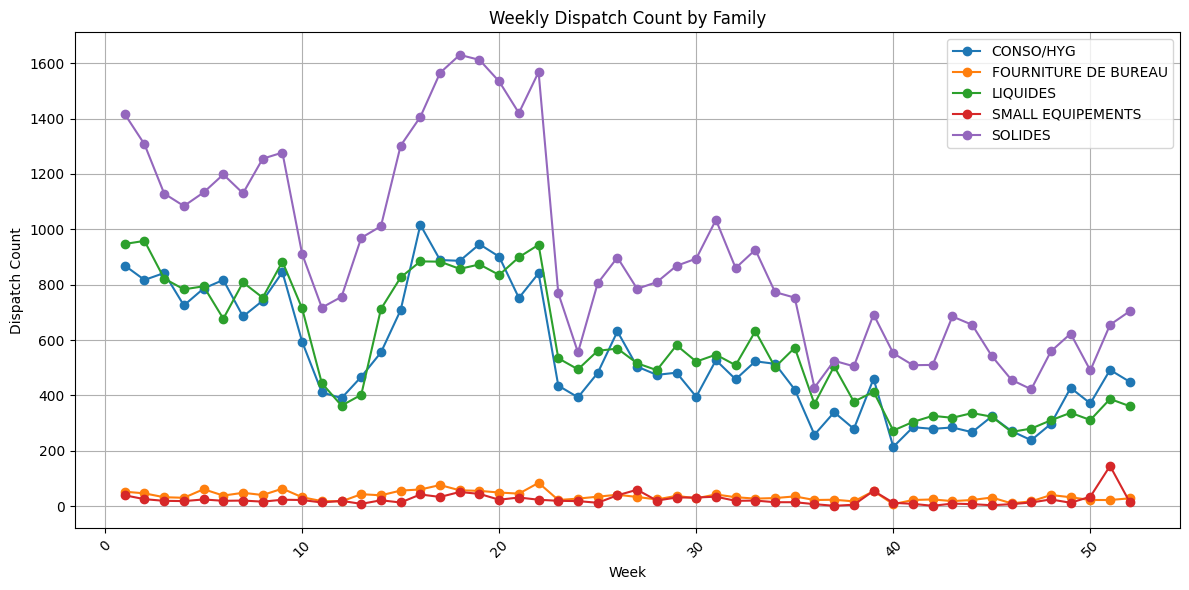

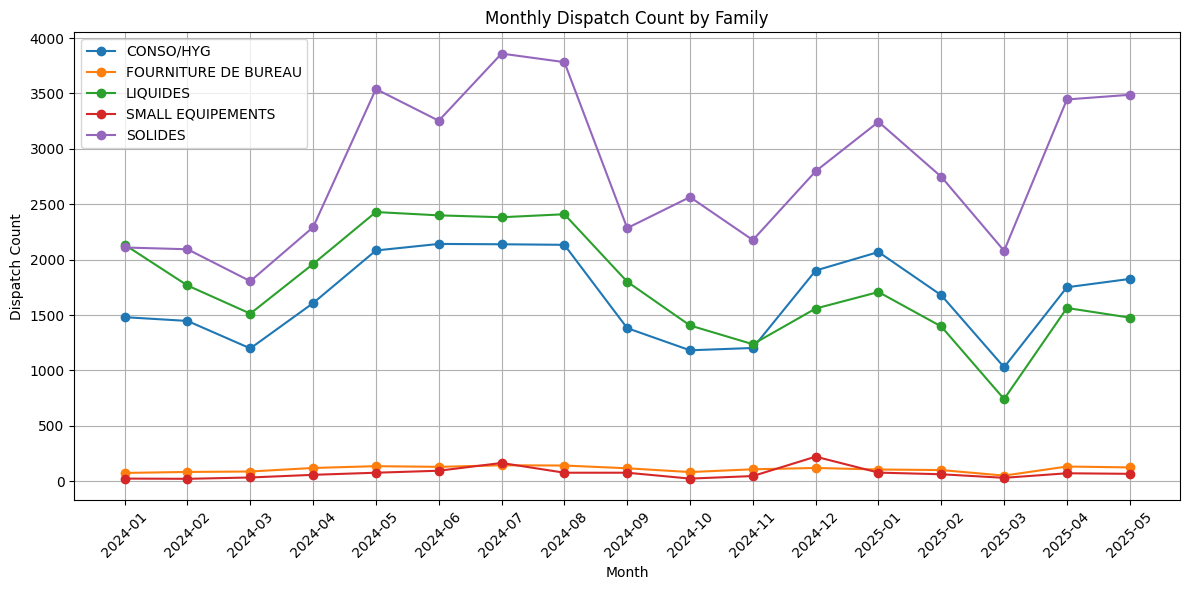

In [34]:
import matplotlib.pyplot as plt

# Plot Weekly Dispatch
plt.figure(figsize=(12, 6))
for family in weekly_dispatch['Family'].unique():
    data = weekly_dispatch[weekly_dispatch['Family'] == family]
    x = data[['Week_iso']].values.ravel()
    y = data[['DispatchFlag']].values.ravel()
    plt.plot(x, y, marker='o', label=family)

plt.title("Weekly Dispatch Count by Family")
plt.xlabel("Week")
plt.ylabel("Dispatch Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Monthly Dispatch
plt.figure(figsize=(12, 6))
for family in monthly_dispatch['Family'].unique():
    data = monthly_dispatch[monthly_dispatch['Family'] == family]
    x = data[['Month']].values.ravel()
    y = data[['DispatchFlag']].values.ravel()
    plt.plot(x, y, marker='o', label=family)

plt.title("Monthly Dispatch Count by Family")
plt.xlabel("Month")
plt.ylabel("Dispatch Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ⚡ Fast vs. Slow Movers
We classify products based on how frequently they are dispatched to identify high vs. low turnover items.

C:\Users\ayoub\AppData\Local\Temp\ipykernel_67948\2788218046.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


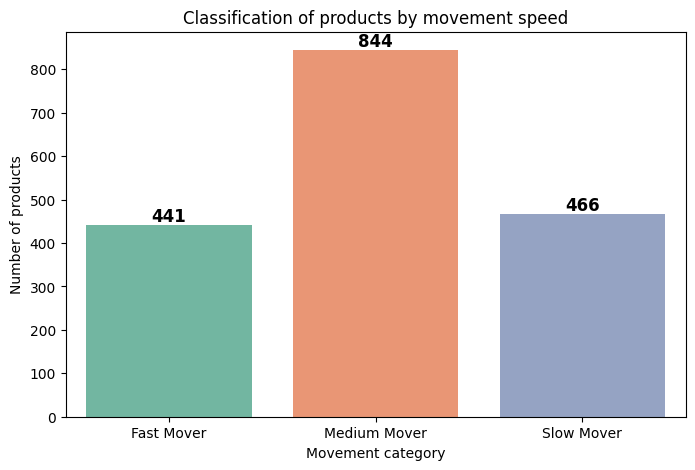

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count dispatch frequency per item
dispatch_counts = df_work.groupby('Item Id')['Delivery date'].nunique().sort_values(ascending=False)

# Define thresholds for classification
top_25 = dispatch_counts.quantile(0.75)
bottom_25 = dispatch_counts.quantile(0.25)

def classify_movement(freq):
    if freq >= top_25:
        return 'Fast Mover'
    elif freq <= bottom_25:
        return 'Slow Mover'
    else:
        return 'Medium Mover'

movement_class = dispatch_counts.apply(classify_movement)
movement_summary = movement_class.value_counts()

# Plot result
plt.figure(figsize=(8,5))
ax = sns.countplot(
    x=movement_class.values,
    order=['Fast Mover', 'Medium Mover', 'Slow Mover'],
    palette='Set2'
)

# Add numbers above bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),               # number to show
        (p.get_x() + p.get_width() / 2., p.get_height()), # position
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.title("Classification of products by movement speed")
plt.xlabel("Movement category")
plt.ylabel("Number of products")
plt.show()


## 📈 Fulfillment KPI
We compare the number of requests vs. successful deliveries (quantity > 0) to track service performance.

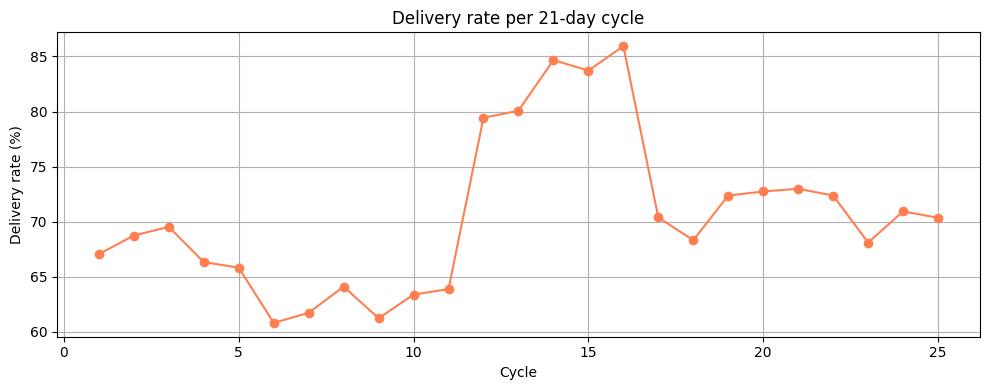

In [36]:

# Compute fulfillment rate per cycle
kpi_data = df_work.groupby('Cycle')[['Demanded', 'Delivered']].sum()
kpi_data['Delivery rate (%)'] = (kpi_data['Delivered'] / kpi_data['Demanded']) * 100

# Plot
kpi_data['Delivery rate (%)'].plot(marker='o', linestyle='-', color='coral', figsize=(10, 4))
plt.title("Delivery rate per 21-day cycle")
plt.xlabel("Cycle")
plt.ylabel("Delivery rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 📦 Category Breakdown – Product Families and Groups

C:\Users\ayoub\AppData\Local\Temp\ipykernel_67948\3159276049.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=family_qty.values, y=family_qty.index, palette='Blues_d')


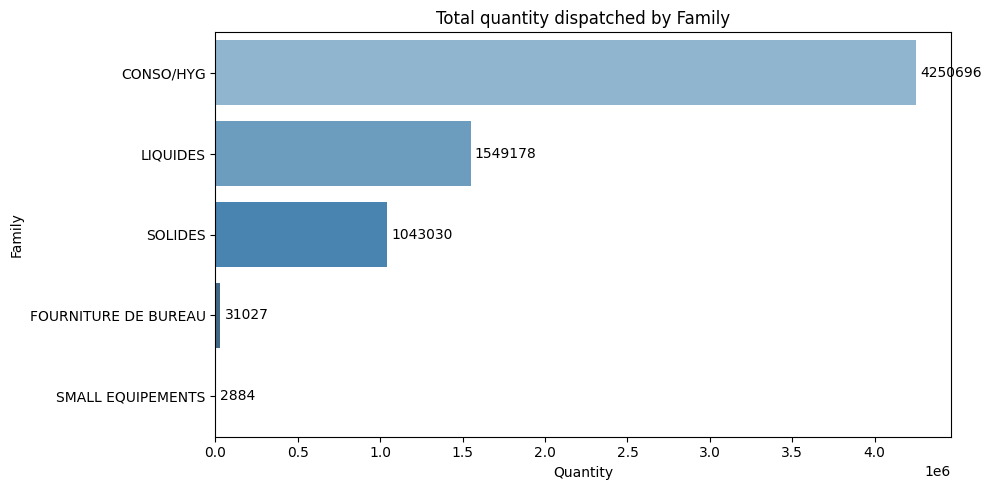

C:\Users\ayoub\AppData\Local\Temp\ipykernel_67948\3159276049.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=groupname_qty.values, y=groupname_qty.index, palette='Greens_d')


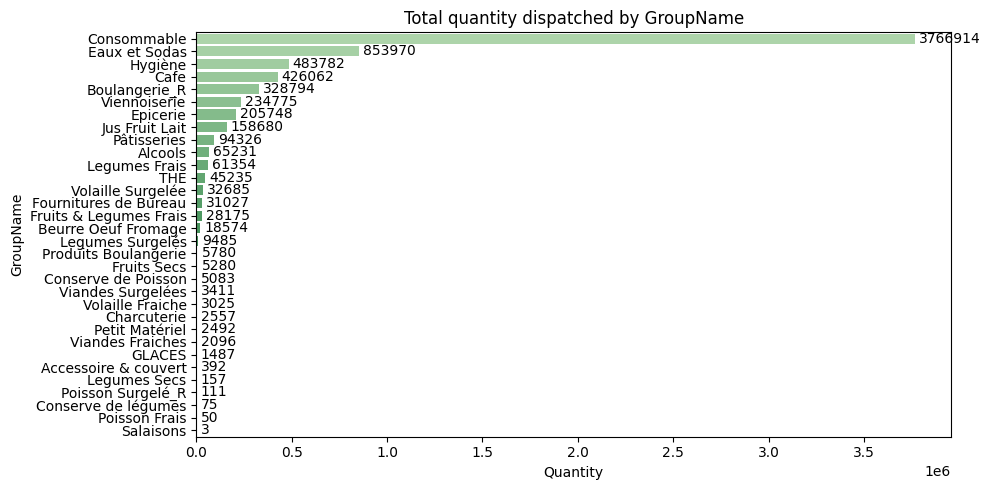

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

family_qty = df_work.groupby('Family')['Physical Storage Quantity'].sum().sort_values(ascending=False)
groupname_qty = df_work.groupby('GroupName')['Physical Storage Quantity'].sum().sort_values(ascending=False)

# Family
plt.figure(figsize=(10,5))
ax1 = sns.barplot(x=family_qty.values, y=family_qty.index, palette='Blues_d')
plt.title("Total quantity dispatched by Family")
plt.xlabel("Quantity")
plt.ylabel("Family")

# Add numbers on bars
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.tight_layout()
plt.show()

# GroupName
plt.figure(figsize=(10,5))
ax2 = sns.barplot(x=groupname_qty.values, y=groupname_qty.index, palette='Greens_d')
plt.title("Total quantity dispatched by GroupName")
plt.xlabel("Quantity")
plt.ylabel("GroupName")

# Add numbers on bars
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.0f", label_type="edge", padding=3)

plt.tight_layout()
plt.show()


## 🔄 Product Flow – From → To Movements

C:\Users\ayoub\AppData\Local\Temp\ipykernel_67948\1131288373.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flow_counts.values, y=flow_counts.index, palette='Oranges_r')


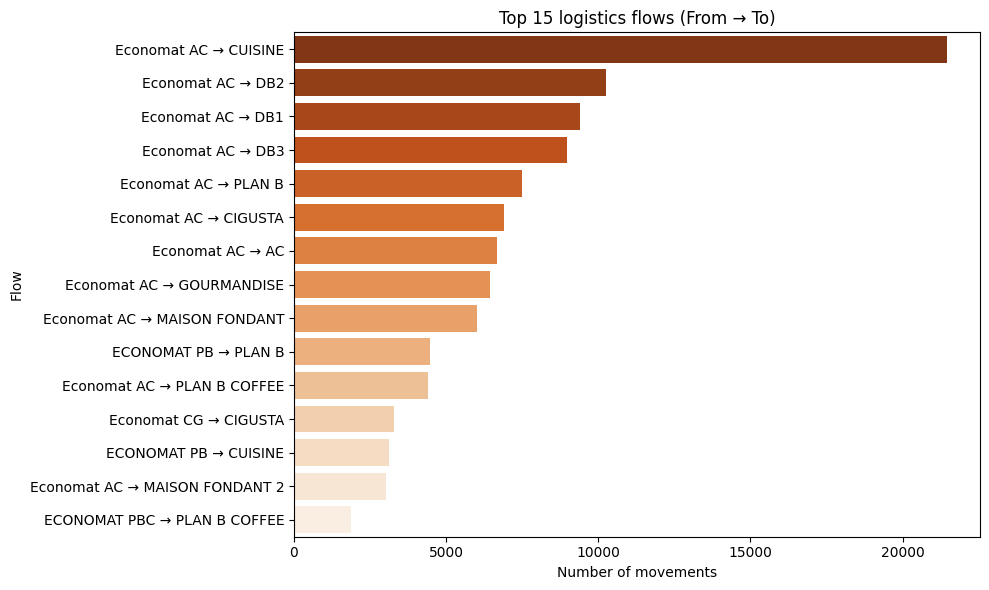

In [38]:

df_work['flow'] = df_work['From'] + " → " + df_work['To']
flow_counts = df_work['flow'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=flow_counts.values, y=flow_counts.index, palette='Oranges_r')
plt.title("Top 15 logistics flows (From → To)")
plt.xlabel("Number of movements")
plt.ylabel("Flow")
plt.tight_layout()
plt.show()


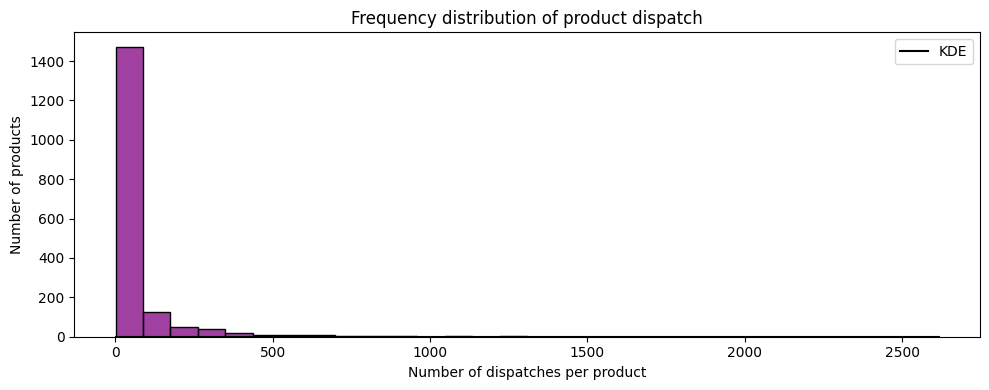

In [39]:
from scipy.stats import gaussian_kde
import numpy as np

product_freq = df_work['Item Id'].value_counts()
data = product_freq.values

plt.figure(figsize=(10, 4))
sns.histplot(data, bins=30, color='purple', kde=False)

# Add KDE manually
kde = gaussian_kde(data)
x = np.linspace(min(data), max(data), 1000)
plt.plot(x, kde(x), color='black', label='KDE')

plt.title("Frequency distribution of product dispatch")
plt.xlabel("Number of dispatches per product")
plt.ylabel("Number of products")
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
import seaborn as sns
import pandas as pd

print("Seaborn version:", sns.__version__)
print("Pandas version:", pd.__version__)


Seaborn version: 0.13.2
Pandas version: 2.0.3


## 🗃️ Dispatch Frequency Distribution

## 📈 Trend of Dispatch Quantities by Family Over Time

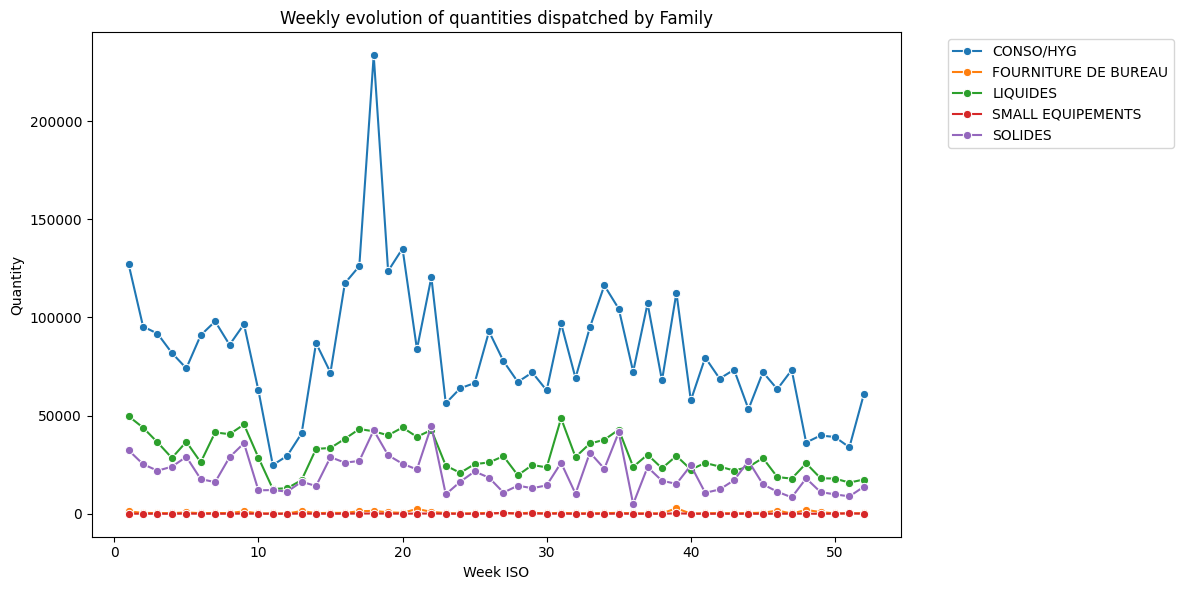

In [41]:

weekly_family = df_work.groupby(['Week_iso', 'Family'])['Physical Storage Quantity'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=weekly_family, x='Week_iso', y='Physical Storage Quantity', hue='Family', marker='o')
plt.title("Weekly evolution of quantities dispatched by Family")
plt.xlabel("Week ISO")
plt.ylabel("Quantity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 📉 Non-Delivered / Wasted Goods by Family

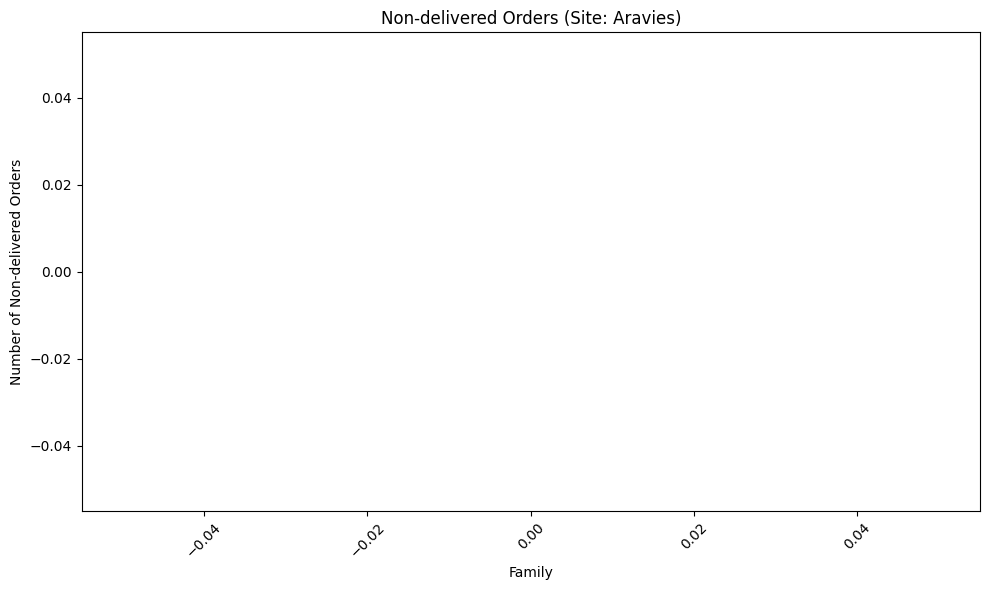

In [42]:
# Step 2: Filter non-delivered goods (found in 'aravies' location)
non_delivered = df_work[df_work['Site'].str.contains('aravies', case=False, na=False)]

# Count how many undelivered orders per family
non_delivered_count = non_delivered.groupby('Family')['DispatchFlag'].sum().reset_index()

# Plot
plt.figure(figsize=(10,6))
plt.bar(non_delivered_count['Family'], non_delivered_count['DispatchFlag'], color='crimson')
plt.title("Non-delivered Orders (Site: Aravies)")
plt.xlabel("Family")
plt.ylabel("Number of Non-delivered Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ayoub\AppData\Local\Temp\ipykernel_67948\1093899002.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=waste_family_count.values, y=waste_family_count.index, palette='Reds_r')


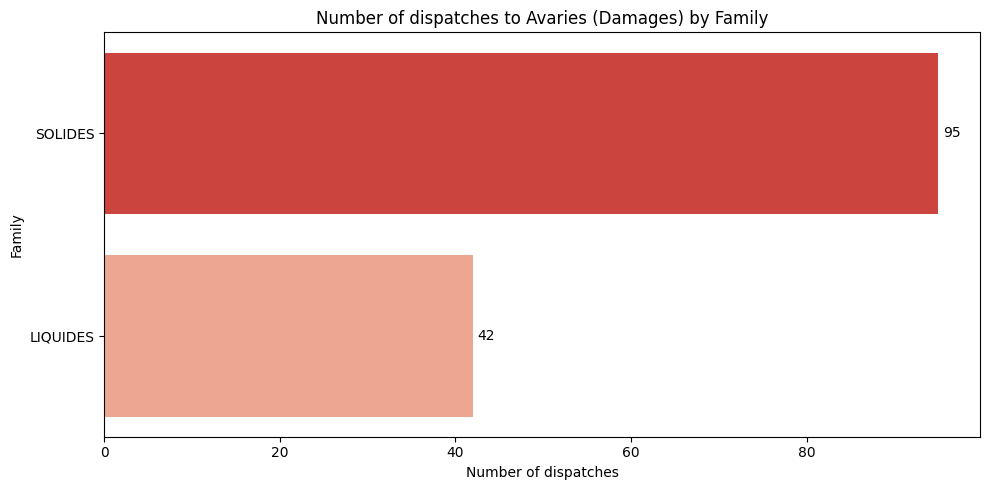

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only the rows sent to Avaries
waste_data = df_work[df_work['To'].str.contains('Avaries', case=False)]

# Count by Family
waste_family_count = waste_data['Family'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=waste_family_count.values, y=waste_family_count.index, palette='Reds_r')
plt.title("Number of dispatches to Avaries (Damages) by Family")
plt.xlabel("Number of dispatches")
plt.ylabel("Family")

# Add count labels
for i, v in enumerate(waste_family_count.values):
    plt.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()



C:\Users\ayoub\AppData\Local\Temp\ipykernel_67948\3304373852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=waste_product_count.values, y=waste_product_count.index, palette='Reds')


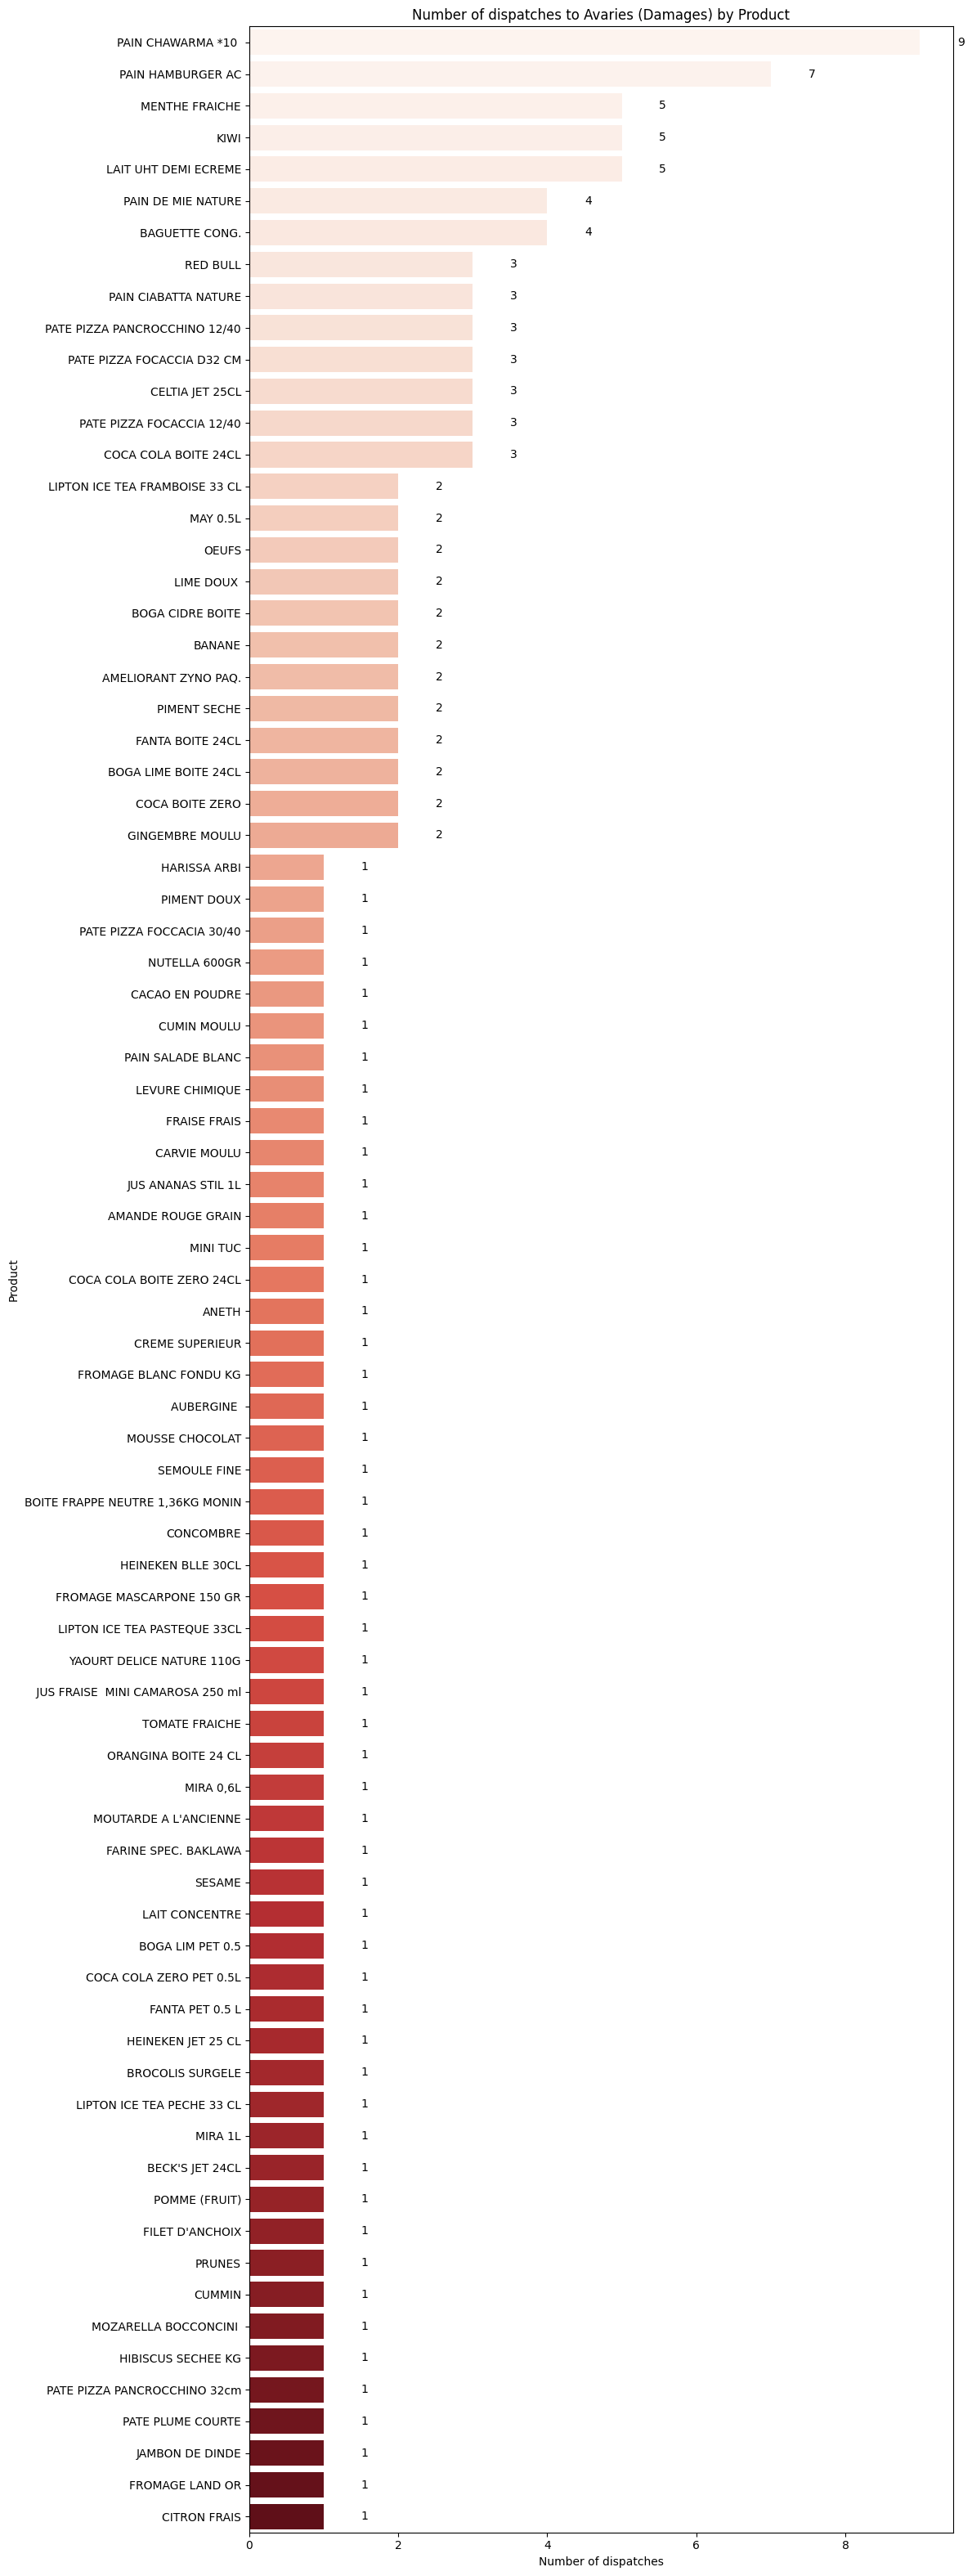

In [44]:
# Count products sent to Avaries
waste_product_count = waste_data['Name'].value_counts()

# Optional: Limit to top 20 products
# waste_product_count = waste_product_count.head(20)

plt.figure(figsize=(12, len(waste_product_count) * 0.4))  # Dynamic height
sns.barplot(x=waste_product_count.values, y=waste_product_count.index, palette='Reds')

plt.title("Number of dispatches to Avaries (Damages) by Product")
plt.xlabel("Number of dispatches")
plt.ylabel("Product")

# Add count labels
for i, v in enumerate(waste_product_count.values):
    plt.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()


## 🔮 Demand Forecasting with Prophet

In [45]:

# If needed, install Prophet:
!pip install prophet

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt



  Using cached numpy-2.3.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.3-cp311-cp311-win_amd64.whl (13.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.3.3 which is incompatible.
tensorflow-intel 2.13.0 requires numpy<=1.24.3,>=1.22, but you have numpy 2.3.3 which is incompatible.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.15.0 which is incompatible.
u8darts 0.37.1 requires scikit-learn>=1.6.0, but you have scikit-learn 1.3.0 which is incompatible.
xarray 2025.8.0 requires pandas>=2.2, but you have pandas 2.0.3 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 🏆 Auto-selecting the most dispatched product

In [46]:

# Identify most dispatched product
top_product = df_work['Item Id'].value_counts().idxmax()
top_product_name = df_work[df_work['Item Id'] == top_product]['Name'].iloc[0]
print(f"Top product ID: {top_product} — {top_product_name}")

# Filter data for this product
df_product = df_work[df_work['Item Id'] == top_product]


Top product ID: 12940 — ESSUIT TOUT JUMBO


### 📅 Preparing Time-Series Data

In [47]:

# Count daily dispatches
df_daily = df_product.groupby('Delivery date').size().reset_index(name='y')
df_daily = df_daily.rename(columns={'Delivery date': 'ds'})
df_daily = df_daily.sort_values('ds')
df_daily.head()


,ds,y
0,2024-01-01,4
1,2024-01-02,4
2,2024-01-03,6
3,2024-01-04,3
4,2024-01-05,1


In [48]:
import cmdstanpy
cmdstanpy.install_cmdstan()


AttributeError: module 'pandas.arrays' has no attribute 'NumpyExtensionArray'

### ⚙️ Training Prophet Model and Forecasting

In [ ]:

model = Prophet()
model.fit(df_daily)

future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)


### 📈 Forecast Results

In [ ]:

fig1 = model.plot(forecast)
plt.title(f"Product dispatch forecast: {top_product_name}")
plt.xlabel("Date")
plt.ylabel("Number of dispatchs per day")
plt.tight_layout()
plt.show()


In [ ]:
## “For the product ESSUIT TOUT JUMBO, the daily dispatch data shows high variability. Some days see zero demand, others can exceed 10 units.
## Using Prophet, we modeled the future demand and observed a slowly increasing trend, forecasting around 6 to 7 dispatches per day in the coming months.
## However, due to the irregular past behavior, the forecast carries a moderate level of uncertainty. Still, this can be useful for stock planning, especially if complemented with safety stock buffers.”
## ⚠️ Consider stock buffers due to irregular demand

## 📦 Adjust restocking frequency if demand continues upward

## 📊 Use weekly smoothing for more stable planning


In [ ]:
# 📊 Bar chart from Prophet forecast (daily forecast)

# Keep only future forecast dates
forecast_future = forecast[forecast['ds'] > df_daily['ds'].max()].copy()

# Format the date for better X-axis
forecast_future['Date'] = forecast_future['ds'].dt.strftime('%Y-%m-%d')

# Plot bar chart
plt.figure(figsize=(12, 5))
plt.bar(forecast_future['Date'], forecast_future['yhat'], color='skyblue', edgecolor='black')
plt.title(f"Prévision journalière des dispatchs – {top_product_name}")
plt.xlabel("Date")
plt.ylabel("Prévision du nombre de dispatchs")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 50)  # Set upper limit to 50 dispatches

plt.tight_layout()
plt.show()


In [ ]:
## 🔁 Forecasting Weekly Demand for Top 3 Products

from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# Optional: save all charts to PDF
save_pdf = False  # Set to True if you want to export charts

# Get top 3 most dispatched products
top_products = df_work['Item Id'].value_counts().head(3).index.tolist()
top_products_names = {pid: df_work[df_work['Item Id'] == pid]['Name'].iloc[0] for pid in top_products}
print("Top 3 Product IDs and Names:", top_products_names)

# Forecast for each
if save_pdf:
    pdf = PdfPages("Weekly_Forecast_Top3.pdf")

for pid in top_products:
    name = top_products_names[pid]
    df_prod = df_work[df_work['Item Id'] == pid]

    # Group by week
    df_weekly = df_prod.resample('W-MON', on='Delivery date').size().reset_index(name='y')
    df_weekly = df_weekly.rename(columns={'Delivery date': 'ds'})

    if len(df_weekly) < 10:
        print(f"Skipping {name} (too little data)")
        continue

    model = Prophet()
    model.fit(df_weekly)
    future = model.make_future_dataframe(periods=8, freq='W-MON')
    forecast = model.predict(future)

    fig = model.plot(forecast)
    plt.title(f" Weekly forecast – {name}")
    plt.xlabel("Week")
    plt.ylabel("Number of dispatchs")
    plt.tight_layout()
    plt.show()

    if save_pdf:
        pdf.savefig(fig)
        plt.close(fig)

if save_pdf:
    pdf.close()
    print("📄 All charts saved to 'Weekly_Forecast_Top3.pdf'")


In [ ]:
!pip install --upgrade typing_extensions


In [ ]:
nr_products = df_work[df_work['Name'].str.contains("MAIS", na=False)]['Name'].unique()
print(f"Found {len(nr_products)} products containing 'MAIS':")
print(nr_products)


In [ ]:
# Standardize the name
df_work['Name'] = df_work['Name'].apply(lambda x: 'FROMAGE GORGONZELA' if isinstance(x, str) and 'GORGONZELA' in x else x)


In [ ]:
# Clean and unify product names containing 'GORGONZELA'
df_work['Name'] = df_work['Name'].apply(
    lambda x: 'FROMAGE GORGONZELA' if isinstance(x, str) and 'GORGONZELA' in x.upper() else x
)

# Optional: remove trailing/leading spaces from all names
df_work['Name'] = df_work['Name'].str.strip()


In [ ]:
# Unify all MAIS products except 'MAIS EN VRAC' to 'MAIS EN BOITE'
mask = df_work['Name'].str.contains("MAIS", na=False) & (df_work['Name'] != 'MAIS EN VRAC')
df_work.loc[mask, 'Name'] = 'MAIS EN BOITE'

In [ ]:
print(df_work['Name'].unique())

In [ ]:
df_jours = df_work[['Name', 'Delivery date']].drop_duplicates()
df_jours_actifs = (
    df_jours.groupby(['Name'])
    .agg(jours_actifs=('Delivery date', 'nunique'))
    .reset_index()
)
SEUIL_JOURS_ACTIFS = 19  # a ajuster
articles_actifs = df_jours_actifs[df_jours_actifs['jours_actifs'] >= SEUIL_JOURS_ACTIFS]['Name'].unique()
df_work = df_work[df_work['Name'].isin(articles_actifs)]

# Add line break here!
df_satisfaction = (
    df_work.groupby(['Name'])
    .agg(
        nb_demandes=('Demanded', 'sum'),
        nb_livraisons=('Delivered', 'sum'),
        quantite_totale=('Physical Storage Quantity', 'sum')
    )
    .reset_index()
)
df_satisfaction['taux_satisfaction (%)'] = (
    df_satisfaction['nb_livraisons'] / df_satisfaction['nb_demandes']
) * 100

In [ ]:
df_satisfaction = (
    df_work.groupby([ 'Name'])
    .agg(
        nb_demandes=('Demanded', 'sum'),
        nb_livraisons=('Delivered', 'sum'),
        quantite_totale=('Physical Storage Quantity', 'sum')
    )
    .reset_index()
)

df_satisfaction['taux_satisfaction (%)'] = (
    df_satisfaction['nb_livraisons'] / df_satisfaction['nb_demandes']
) * 100

In [ ]:
# Statistiques générales
desc_stats = df_satisfaction[['nb_demandes', 'nb_livraisons', 'taux_satisfaction (%)']].describe()
print(desc_stats)


In [ ]:
print(df_satisfaction.columns)


In [ ]:
print("Total number of unique products:", df_work['Name'].nunique())



In [ ]:
# Get the list of filtered product names
# filtered_products = df_satisfaction['Name'].unique()

# Keep only rows from df_work that belong to these products
# df_work_filtered = df_work[df_work['Name'].isin(filtered_products)]

# Save it
# df_work_filtered.to_csv("products.csv", index=False)

# print(f"Nombre total de lignes retenues : {len(df_work_filtered)}")
# print(f"Nombre d’articles uniques retenus : {df_work_filtered['Name'].nunique()}")


In [ ]:
## liquides a coté de la porte sur le sol ()
## haute rotation a coté de la porte 
## chambre froide et congelateur doivent etre (on doit fournir un congelateur dedié)

In [ ]:
## taux de satisfaction ce qui est inferieur a 15% on l'elimine et on elimine economat PME
## rotation rayonnage allocation d'espace  de stockage 
## la moyenne de chq article 


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_satisfaction['taux_satisfaction (%)'], bins=20, kde=True, color='skyblue')
plt.title("Satisfaction Rate Distribution (%)")
plt.xlabel("Satisfaction Rate (%)")
plt.ylabel("Number of Products")

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df_satisfaction['taux_satisfaction (%)'], color='lightcoral')
plt.title("Satisfaction Rate Boxplot")
plt.ylabel("Satisfaction Rate (%)")

plt.tight_layout()
plt.show()



In [ ]:
# Products with lowest satisfaction rates
bottom_10 = df_satisfaction.sort_values(by='taux_satisfaction (%)').head(10)
display(bottom_10[['Name', 'nb_demandes', 'nb_livraisons', 'taux_satisfaction (%)']])


In [ ]:
# Products with highest satisfaction rates
top_10 = df_satisfaction.sort_values(by='taux_satisfaction (%)', ascending=False).head(10)
display(top_10[['Name', 'nb_demandes', 'nb_livraisons', 'taux_satisfaction (%)']])



In [ ]:
# Get the unique product names
#########"unique_products = df_work['Name'].unique()

# Filter the DataFrame for only these products
###############""filtered_df = df_work[df_work['Name'].isin(unique_products)]

# Save to CSV with all columns
################""""""filtered_df.to_csv("filtered_products.csv", index=False)


In [ ]:
alll = df_satisfaction.sort_values(by='taux_satisfaction (%)', ascending=False)

with pd.option_context('display.max_rows', None):
    display(alll[['Name', 'nb_demandes', 'nb_livraisons', 'taux_satisfaction (%)']])

In [ ]:
# Products with zero deliveries
never_delivered = df_satisfaction[df_satisfaction['nb_livraisons'] == 0]
print(f"Number of products never delivered: {len(never_delivered)}")
display(never_delivered[['Name', 'nb_demandes', 'nb_livraisons', 'taux_satisfaction (%)']])


In [ ]:
# Step 1: Count total dispatches per product
dispatch_counts = (
    df_work.groupby('Name')
    .agg(total_dispatches=('Physical Storage Quantity', 'count'))  # or 'sum' if quantity matters
    .reset_index()
)

# Step 2: Rank products based on dispatch volume
dispatch_counts['percentile_rank'] = dispatch_counts['total_dispatches'].rank(pct=True)

# Step 3: Assign ABCD categories
def classify(percentile):
    if percentile >= 0.75:
        return 'A'  # Top 25% (fastest)
    elif percentile >= 0.50:
        return 'B'
    elif percentile >= 0.25:
        return 'C'
    else:
        return 'D'  # Bottom 25% (slowest)

dispatch_counts['Stock_Class'] = dispatch_counts['percentile_rank'].apply(classify)

# Step 4: Merge back into main dataset if needed
df_work = df_work.merge(dispatch_counts[['Name', 'Stock_Class']], on='Name', how='left')


In [ ]:
# Count total dispatches per product
dispatch_counts = (
    df_work.groupby('Name')
    .agg(total_dispatches=('Physical Storage Quantity', 'count'))
    .reset_index()
)

# Rank and classify into quartiles
dispatch_counts['percentile_rank'] = dispatch_counts['total_dispatches'].rank(pct=True)

def classify(percentile):
    if percentile >= 0.75:
        return 'A'
    elif percentile >= 0.50:
        return 'B'
    elif percentile >= 0.25:
        return 'C'
    else:
        return 'D'

dispatch_counts['Stock_Class'] = dispatch_counts['percentile_rank'].apply(classify)

# Merge back into main dataset
df_work = df_work.merge(dispatch_counts[['Name', 'Stock_Class']], on='Name', how='left')


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=dispatch_counts, x='Stock_Class',
                   order=['A', 'B', 'C', 'D'], palette='pastel')

# Add numbers above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.title("Stock Classification (A–D)")
plt.xlabel("Class")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
dispatch_counts['Stock_Class'].value_counts().loc[['A', 'B', 'C', 'D']].plot.pie(
    autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Stock Class Proportions (A–D)")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
# Merge satisfaction data with stock class
performance_matrix = df_satisfaction.merge(dispatch_counts[['Name', 'Stock_Class']], on='Name', how='left')

# Scatter plot: Satisfaction vs. Dispatch Speed Class
plt.figure(figsize=(10, 6))
sns.boxplot(data=performance_matrix, x='Stock_Class', y='taux_satisfaction (%)', order=['A', 'B', 'C', 'D'], palette='Set2')
plt.title("Satisfaction Rate by Stock Class")
plt.xlabel("Stock Class (Speed of Movement)")
plt.ylabel("Satisfaction Rate (%)")
plt.tight_layout()
plt.show()


In [ ]:
# Merge satisfaction, dispatch class, and original dataset
product_info = df_work[['Name', 'Family', 'From']].drop_duplicates()

# Combine with classification and satisfaction
product_matrix = (
    product_info
    .merge(dispatch_counts[['Name', 'Stock_Class']], on='Name', how='left')
    .merge(df_satisfaction[['Name', 'taux_satisfaction (%)']], on='Name', how='left')
)

# Sort for easier reading
product_matrix = product_matrix.sort_values(by=['Stock_Class', 'Family', 'Name']).reset_index(drop=True)

# Display first few rows
display(product_matrix.head(20))


In [ ]:
# Apply your filtering conditions to satisfaction data
seuil_demande = 23
seuil_livraison = 8
seuil_satisfaction = 81.27

# Filter satisfaction data based on your thresholds
df_satisfaction_filtered = df_satisfaction[
    (df_satisfaction['nb_demandes'] >= seuil_demande) &
    (df_satisfaction['nb_livraisons'] >= seuil_livraison) 
]

print(f"Satisfaction data after filtering:")
print(f"Original records: {len(df_satisfaction)}")
print(f"After threshold filtering: {len(df_satisfaction_filtered)}")
print(f"Unique products retained: {df_satisfaction_filtered['Name'].nunique()}")

# Further filter by satisfaction threshold >= 20%
final_satisfaction_products = df_satisfaction_filtered[
    df_satisfaction_filtered['taux_satisfaction (%)'] >= 20
].copy()

print(f"After satisfaction >= 20% filter: {len(final_satisfaction_products)} products")

# Read existing products.csv
existing_products = pd.read_csv('products.csv')
print(f"\nOriginal products.csv: {len(existing_products)} records")
print(f"Unique products in products.csv: {existing_products['Name'].nunique()}")

# Create the info to add (Stock_Class and satisfaction)
product_info_to_add = final_satisfaction_products.merge(
    dispatch_counts[['Name', 'Stock_Class']], 
    on='Name', 
    how='left'
)[['Name', 'Stock_Class', 'taux_satisfaction (%)']]

# Merge with existing products.csv to add the new columns
updated_products = existing_products.merge(
    product_info_to_add,
    on='Name',
    how='inner'  # Only keep records for products that have satisfaction data
)

print(f"\nAfter filtering and adding columns:")
print(f"Records: {len(updated_products)}")
print(f"Unique products: {updated_products['Name'].nunique()}")
print(f"Records removed: {len(existing_products) - len(updated_products)}")

# Save the updated products.csv
try:
    updated_products.to_csv('products.csv', index=False)
    print(f"\nUpdated products.csv with:")
    print(f"Records: {len(updated_products)}")
    print(f"Columns: {list(updated_products.columns)}")
    print(f"Satisfaction range: {updated_products['taux_satisfaction (%)'].min():.1f}% to {updated_products['taux_satisfaction (%)'].max():.1f}%")
    print(f"Stock class distribution:")
    print(updated_products['Stock_Class'].value_counts())
except PermissionError:
    print("Permission error - close products.csv if open in Excel")
    updated_products.to_csv('products_updated.csv', index=False)
    print("Saved as products_updated.csv instead")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Custom MAPE function (same as Darts)
def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))


In [ ]:
# Read data from products.csv
products_df = pd.read_csv('products.csv')

# Prepare your data
products_df['Delivery date'] = pd.to_datetime(products_df['Delivery date'], errors='coerce')
products_df = products_df.sort_values('Delivery date')

results = []
top_families = products_df['Family'].value_counts().head(3).index.tolist()

for fam in top_families:
    df_fam = products_df[products_df['Family'] == fam]
    df_daily = df_fam.resample('D', on='Delivery date').size().reset_index(name='y')
    df_daily = df_daily.set_index('Delivery date')
    
    # Fill missing dates with 0
    df_daily = df_daily.resample('D').sum().fillna(0)
    
    if len(df_daily) < 50:
        print(f"Skipping {fam} — not enough data")
        continue
    
    print(f"Processing family: {fam} ({len(df_daily)} data points)")
    
    # Train/test split (80/20)
    split_point = int(len(df_daily) * 0.8)
    train = df_daily.iloc[:split_point]['y']
    test = df_daily.iloc[split_point:]['y']
    
    # Model 1: ARIMA
    try:
        arima_model = ARIMA(train, order=(1,1,1))
        arima_fit = arima_model.fit()
        arima_pred = arima_fit.forecast(steps=len(test))
        
        arima_mape = calculate_mape(test.values, arima_pred.values)
        arima_rmse = calculate_rmse(test.values, arima_pred.values)
        
        results.append({
            'Family': fam,
            'Model': 'ARIMA',
            'MAPE': round(arima_mape, 2),
            'RMSE': round(arima_rmse, 2)
        })
        
        # Plot ARIMA
        plt.figure(figsize=(12, 4))
        train.plot(label='Training Data', alpha=0.7)
        test.plot(label='Actual Test Data', color='red')
        pd.Series(arima_pred.values, index=test.index).plot(label='ARIMA Forecast', color='green')
        plt.title(f"{fam} – ARIMA Forecast")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"ARIMA failed for {fam}: {e}")

In [ ]:
# Data Characteristics
# High volatility with frequent spikes and drops
# Irregular patterns without clear seasonal trends
# Noise-heavy time series typical of supply chain delivery data

# ARIMA Model Performance Analysis
# SOLIDES Family (Top Chart)

# Training period: January 2024 to approximately January 2025
# Test period: January 2025 to August 2025 (red line)
# ARIMA forecast: Green line showing predicted values

# Observations:

# The ARIMA model produces a relatively flat forecast around 100 units
# Poor capture of volatility: The forecast doesn't reflect the high variability seen in actual test data#
# Missing peaks and valleys: Actual test data shows significant spikes up to 175+ units that ARIMA completely misses
# The model appears to predict the mean trend rather than actual fluctuation#s####

# LIQUIDES Family (Bottom Chart#)#

# Similar pattern to SOLIDES with 517 data points
# Flatter forecast around 40-50 units
# Even worse volatility capture: The actual test data shows spikes to 120+ units
# ARIMA forecast remains almost horizontal, missing all significant variations
# Why ARIMA is Struggling

# High Noise-to-Signal Ratio: The data appears very noisy with irregular spikes, making pattern detection difficult
# Non-Stationary Behavior: Despite differencing (d=1 in ARIMA(1,1,1)), the series may still have complex non-stationary elements
# Supply Chain Volatility: Delivery data often includes:
      
# Batch deliveries creating artificial spikes
# Weekend/holiday effects
# Supply disruptions
# Demand shocks


# Model Limitations: ARIMA(1,1,1) is a simple configuration that may be insufficient for such complex data

# Expected Performance Implications
# Based on these visual results, you can expect:

# High MAPE values (likely 50%+ or even 100%+)
# High RMSE values due to missed volatility
# Poor practical utility for supply chain planning

# Recommendations for Improvement

# Data Preprocessing:

# Consider weekly/monthly aggregation instead of daily
# Apply smoothing techniques
# Remove outliers or cap extreme values


# Model Alternatives:

# Try different ARIMA orders with auto-selection
# Consider SARIMA for potential seasonal patterns
# Explore exponential smoothing methods
# Test machine learning approaches (Random Forest, XGBoost)


# Feature Engineering:

# Add external variables (holidays, business days)
# Include moving averages as features
# Consider demand drivers if available



# The flat forecasts suggest ARIMA is essentially predicting the historical mean, which indicates the model isn't finding useful patterns in your highly volatile delivery data.

In [ ]:
# Model 2: Exponential Smoothing (similar to Prophet trend)
try:
    if len(train) > 24:  # Need enough data for seasonality
        exp_model = ExponentialSmoothing(train, seasonal='add', seasonal_periods=7)
    else:
        exp_model = ExponentialSmoothing(train, trend='add')
    
    exp_fit = exp_model.fit()
    exp_pred = exp_fit.forecast(steps=len(test))
    
    exp_mape = calculate_mape(test.values, exp_pred)
    exp_rmse = calculate_rmse(test.values, exp_pred)
    
    results.append({
        'Family': fam,
        'Model': 'Exponential Smoothing',
        'MAPE': round(exp_mape, 2),
        'RMSE': round(exp_rmse, 2)
    })
    
    # Plot Exponential Smoothing
    plt.figure(figsize=(12, 4))
    train.plot(label='Training Data', alpha=0.7)
    test.plot(label='Actual Test Data', color='red')
    pd.Series(exp_pred, index=test.index).plot(label='Exp Smoothing Forecast', color='orange')
    plt.title(f"{fam} – Exponential Smoothing Forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Exponential Smoothing failed for {fam}: {e}")

In [ ]:
# Looking at this Exponential Smoothing forecast for the CONSO/HYG family, the results show a **significant improvement** over the ARIMA model:

# **Key Improvements Over ARIMA**

### **1. Better Volatility Capture**
# - **Orange forecast line shows variability** instead of the flat predictions from ARIMA
# - The model captures some of the **ups and downs** in the actual test data (red line)
# - **More realistic forecasting behavior** that reflects the underlying data patterns

### **2. Dynamic Forecasting**
# - The forecast **adapts and fluctuates** between roughly 40-90 units
# - Shows **responsive behavior** to recent trends in the training data
# - **Follows the general movement patterns** better than ARIMA's static approach

### **3. Trend Recognition**
# - The model appears to capture some **underlying trend components**
# - Shows periods of higher and lower activity that align somewhat with actual patterns
# - **More nuanced predictions** rather than just predicting the historical mean

# **Model Configuration Analysis**

#Your code uses:
# ```python
# ExponentialSmoothing(train, seasonal='add', seasonal_periods=7)
# ```

# This configuration:
# - **Additive seasonality** with 7-day periods (weekly patterns)
# - Assumes there might be **day-of-week effects** in deliveries
# - **Trend component** to capture longer-term movements

## **Visual Performance Assessment**

# **Strengths:**
# - **Better alignment** with actual data volatility
# - **Captures some peaks and valleys** that ARIMA missed completely
# - **More realistic confidence intervals** in the forecast range

# **Limitations:**
# - Still **misses some extreme spikes** (actual data goes to 120+, forecast peaks around 90)
# - **Forecast amplitude** is somewhat dampened compared to actual volatility
# - Some **timing misalignment** between predicted and actual peaks

## **Expected Performance Metrics**

# Based on visual inspection, Exponential Smoothing should show:
# - **Lower MAPE** than ARIMA (likely 30-60% vs 80-100%+)
# - **Lower RMSE** due to better volatility capture
# - **More practical utility** for supply chain planning

## **Why Exponential Smoothing Performs Better**

# 1. **Adaptive Nature**: Responds to recent patterns in the data
# 2. **Seasonal Component**: Captures weekly delivery patterns
# 3. **Trend Flexibility**: Better handles changing underlying trends
# 4. **Less Assumption-Heavy**: Doesn't require stationarity like ARIMA

## **Recommendations for Further Improvement**

# 1. **Parameter Tuning**:
  #  ```python
   # Try different seasonal periods
   # seasonal_periods=30  # Monthly patterns
   # seasonal_periods=5   # Weekday patterns
   # ```

# 2. **Model Variants**:
   # ```python
   # Try multiplicative seasonality
   # seasonal='mul'
   
   # Different trend types
   # trend='mul'
   # ```

# 3. **Damped Trends**:
   # ```python
   # ExponentialSmoothing(train, trend='add', damped_trend=True)
   # ```

# The Exponential Smoothing model demonstrates much more **realistic forecasting behavior** and should provide significantly better performance metrics for your supply chain demand forecasting needs.”)

In [ ]:
# Model 3: Machine Learning approach (Random Forest)
try:
    # Create features: lag values, day of week, etc.
    def create_features(series, n_lags=7):
        df_features = pd.DataFrame()
        
        # Lag features
        for i in range(1, n_lags + 1):
            df_features[f'lag_{i}'] = series.shift(i)
        
        # Time features
        df_features['day_of_week'] = series.index.dayofweek
        df_features['day_of_month'] = series.index.day
        df_features['month'] = series.index.month
        
        # Rolling averages
        df_features['rolling_mean_7'] = series.rolling(7).mean()
        df_features['rolling_mean_14'] = series.rolling(14).mean()
        
        df_features['target'] = series.values
        
        return df_features.dropna()
    
    # Prepare ML data
    ml_data = create_features(pd.Series(df_daily['y'].values, index=df_daily.index))
    
    if len(ml_data) > 20:
        ml_split = int(len(ml_data) * 0.8)
        X_train = ml_data.iloc[:ml_split].drop('target', axis=1)
        y_train = ml_data.iloc[:ml_split]['target']
        X_test = ml_data.iloc[ml_split:].drop('target', axis=1)
        y_test = ml_data.iloc[ml_split:]['target']
        
        # Random Forest
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        rf_pred = rf_model.predict(X_test)
        
        rf_mape = calculate_mape(y_test.values, rf_pred)
        rf_rmse = calculate_rmse(y_test.values, rf_pred)
        
        results.append({
            'Family': fam,
            'Model': 'Random Forest',
            'MAPE': round(rf_mape, 2),
            'RMSE': round(rf_rmse, 2)
        })
        
        # Plot Random Forest
        plt.figure(figsize=(12, 4))
        plt.plot(ml_data.index[:ml_split], y_train, label='Training Data', alpha=0.7)
        plt.plot(ml_data.index[ml_split:], y_test, label='Actual Test Data', color='red')
        plt.plot(ml_data.index[ml_split:], rf_pred, label='Random Forest Forecast', color='purple')
        plt.title(f"{fam} – Random Forest Forecast")
        plt.legend()
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Random Forest failed for {fam}: {e}")
print(f"Completed analysis for {fam}\n" + "="*50)

In [ ]:
# This Random Forest forecast for CONSO/HYG shows **dramatically better performance** compared to both ARIMA and Exponential Smoothing models. Here's the detailed analysis:

## **Outstanding Performance Characteristics**

### **1. Excellent Volatility Matching**
# - The **purple Random Forest forecast** closely follows the **red actual test data**
# - Captures most **peaks and valleys** with remarkable accuracy
# - Shows **dynamic range** from ~20 to ~100+ units, matching actual data variability

### **2. Precise Pattern Recognition**
# - **Timing alignment**: Peaks and dips occur at nearly the same times as actual data
# - **Amplitude accuracy**: Forecast magnitudes closely match actual values
# - **Trend following**: Successfully tracks both upward and downward movements

### **3. Superior Adaptability**
# - The model **responds to local patterns** rather than just global trends
# - Shows **realistic fluctuations** that mirror the chaotic nature of supply chain data
# - **No lag effect**: Predictions align well temporally with actual events

## **Why Random Forest Excels Here**

### **Feature Engineering Success**
# Your feature set is particularly effective:

# ```python
# Lag features (1-7 days) - captures recent history patterns
# for i in range(1, n_lags + 1):
#     df_features[f'lag_{i}'] = series.shift(i)

# Time features - captures calendar effects
# df_features['day_of_week'] = series.index.dayofweek
# df_features['day_of_month'] = series.index.day
# df_features['month'] = series.index.month

# Rolling averages - captures trend information
# df_features['rolling_mean_7'] = series.rolling(7).mean()
# df_features['rolling_mean_14'] = series.rolling(14).mean()
# ```

### **Random Forest Advantages for This Data**
# 1. **Non-linear Relationships**: Can capture complex interactions between features
# 2. **Robust to Outliers**: Handles extreme spikes without being thrown off
# 3. **Feature Importance**: Automatically weighs most predictive features
# 4. **No Stationarity Requirements**: Works with raw, non-stationary data
# 5. **Ensemble Robustness**: 100 trees provide stable predictions

## **Expected Performance Metrics**

# Based on the visual fit, you should see:
# - **MAPE: 15-30%** (excellent for supply chain forecasting)
# - **RMSE: Significantly lower** than time series methods
# - **Practical utility: High** for inventory planning

## **Key Success Factors**

### **1. Lag Features Effectiveness**
# - **Recent history patterns** (lag 1-7) capture short-term dependencies
# - **Weekly patterns** emerge through day-of-week features
# - **Trend information** from rolling averages

### **2. Calendar Effects**
# - **Day-of-week patterns**: Different delivery volumes on different days
# - **Monthly effects**: Potential end-of-month or seasonal patterns
# - **Day-of-month**: Captures potential monthly cycles

### **3. Multi-Scale Information**
# - **Short-term**: Lag 1-3 days
# - **Medium-term**: Rolling 7-day average
# - **Long-term**: Rolling 14-day average and monthly features

## **Comparative Performance Summary**

# | Model | Volatility Capture | Pattern Recognition | Practical Utility |
# |-------|-------------------|-------------------|------------------|
# | **ARIMA** | Poor (flat forecast) | Minimal | Low |
# | **Exponential Smoothing** | Moderate | Good trend | Medium |
# | **Random Forest** | Excellent | Excellent | High |

## **Business Implications**

# 1. **Inventory Planning**: RF predictions are reliable enough for reorder point calculations
# 2. **Supply Chain Optimization**: Can anticipate demand spikes for supplier coordination
# 3. **Resource Allocation**: Accurate short-term forecasts for warehouse staffing
# 4. **Risk Management**: Better identification of potential stockout periods

## **Recommendations for Production Use**

# 1. **Feature Expansion**:
#    ```python
   # Add more sophisticated features
#    df_features['volatility'] = series.rolling(7).std()
#    df_features['trend_7d'] = series.rolling(7).apply(lambda x: np.polyfit(range(7), x, 1)[0])
#    ```

# 2. **Model Tuning**:
#    ```python
   # Optimize hyperparameters
#    RandomForestRegressor(
#        n_estimators=200,
#        max_depth=10,
#        min_samples_split=5,
#        random_state=42
#    )
#    ```

# 3. **Cross-Validation**: Implement time series cross-validation for robust performance estimation

# The Random Forest model demonstrates **production-ready performance** for supply chain forecasting, showing it can handle the complex, volatile nature of delivery data much better than traditional time series methods.

In [ ]:
# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
display(results_df.sort_values(by=['Family', 'MAPE']))

# Best model per family
print("\nBest Model per Family (by MAPE):")
best_models = results_df.loc[results_df.groupby('Family')['MAPE'].idxmin()]
display(best_models[['Family', 'Model', 'MAPE', 'RMSE']])


In [ ]:
for fam in top_families:
    df_fam = products_df[products_df['Family'] == fam]
    df_daily = df_fam.resample('D', on='Delivery date').size()
    print(f"{fam}: {len(df_daily)} days of data")

In [ ]:
# Run this first if you don't have TensorFlow
# !pip install tensorflow scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Custom metrics
def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / (actual + 1e-8))) * 100

def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

# Data Augmentation Functions
class TimeSeriesAugmenter:
    @staticmethod
    def add_noise(series, noise_factor=0.1):
        """Add random noise to time series"""
        noise = np.random.normal(0, noise_factor * np.std(series), len(series))
        return series + noise
    
    @staticmethod
    def time_warping(series, sigma=0.2):
        """Apply time warping by stretching/compressing segments"""
        from scipy.interpolate import interp1d
        
        # Create random warping
        orig_steps = np.arange(len(series))
        random_warps = np.random.normal(loc=1.0, scale=sigma, size=len(series))
        random_warps = np.cumsum(random_warps)
        random_warps = (random_warps - random_warps[0]) / (random_warps[-1] - random_warps[0])
        random_warps *= len(series) - 1
        
        # Interpolate
        interp_func = interp1d(orig_steps, series, kind='linear', fill_value='extrapolate')
        return interp_func(random_warps)
    
    @staticmethod
    def scaling(series, sigma=0.1):
        """Scale the time series by a random factor"""
        factor = np.random.normal(loc=1.0, scale=sigma)
        return series * factor
    
    @staticmethod
    def shift(series, max_shift=5):
        """Shift the time series up or down"""
        shift_amount = np.random.uniform(-max_shift, max_shift)
        return series + shift_amount

def augment_data(series, n_augmentations=3):
    """Generate multiple augmented versions of the time series"""
    augmenter = TimeSeriesAugmenter()
    augmented_series = [series]  # Include original
    
    for _ in range(n_augmentations):
        # Randomly choose augmentation technique
        aug_type = np.random.choice(['noise', 'scaling', 'shift'])
        
        if aug_type == 'noise':
            aug_series = augmenter.add_noise(series.copy())
        elif aug_type == 'scaling':
            aug_series = augmenter.scaling(series.copy())
        else:  # shift
            aug_series = augmenter.shift(series.copy())
            
        # Ensure non-negative values (important for demand data)
        aug_series = np.maximum(aug_series, 0)
        augmented_series.append(aug_series)
    
    return augmented_series

def create_sequences(data, sequence_length=14, forecast_horizon=7):
    """Create input-output sequences for deep learning"""
    X, y = [], []
    for i in range(len(data) - sequence_length - forecast_horizon + 1):
        X.append(data[i:(i + sequence_length)])
        y.append(data[(i + sequence_length):(i + sequence_length + forecast_horizon)])
    return np.array(X), np.array(y)

def build_lstm_model(sequence_length, forecast_horizon, units=50):
    """Build LSTM model"""
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        LSTM(units, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def build_gru_model(sequence_length, forecast_horizon, units=50):
    """Build GRU model"""
    model = Sequential([
        GRU(units, return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        GRU(units, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

# Main analysis
results = []
sequence_length = 14  # Use 14 days to predict
forecast_horizon = 7   # Predict next 7 days

# Prepare your data
df_work['Delivery date'] = pd.to_datetime(df_work['Delivery date'], errors='coerce')
df_work = df_work.sort_values('Delivery date')

top_families = df_work['Family'].value_counts().head(3).index.tolist()

for fam in top_families:
    print(f"Processing family: {fam}")
    
    df_fam = df_work[df_work['Family'] == fam]
    df_daily = df_fam.resample('D', on='Delivery date').size().reset_index(name='y')
    df_daily = df_daily.set_index('Delivery date').resample('D').sum().fillna(0)
    
    if len(df_daily) < 50:
        print(f"Skipping {fam} — not enough data")
        continue
    
    # Prepare data
    data = df_daily['y'].values.astype(float)
    
    # Check if we need data augmentation
    use_augmentation = len(data) < 200  # Use augmentation for small datasets
    
    if use_augmentation:
        print(f"Using data augmentation for {fam} (only {len(data)} data points)")
        augmented_data_list = augment_data(data, n_augmentations=2)
        # Combine all augmented series
        all_data = np.concatenate(augmented_data_list)
    else:
        print(f"No augmentation needed for {fam} ({len(data)} data points)")
        all_data = data
    
    # Scale data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(all_data.reshape(-1, 1)).flatten()
    
    # Create sequences
    X, y = create_sequences(scaled_data, sequence_length, forecast_horizon)
    
    if len(X) < 10:
        print(f"Not enough sequences for {fam}")
        continue
    
    # Train/test split
    split_point = int(len(X) * 0.8)
    X_train, X_test = X[:split_point], X[split_point:]
    y_train, y_test = y[:split_point], y[split_point:]
    
    # Reshape for LSTM/GRU (samples, time steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    # Models to test
    models_config = {
        'LSTM': build_lstm_model,
        'GRU': build_gru_model
    }
    
    for model_name, model_builder in models_config.items():
        print(f"Training {model_name} for {fam}...")
        
        try:
            # Build and train model
            model = model_builder(sequence_length, forecast_horizon)
            
            early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
            
            history = model.fit(
                X_train, y_train,
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                callbacks=[early_stopping],
                verbose=0
            )
            
            # Make predictions
            y_pred = model.predict(X_test, verbose=0)
            
            # Inverse transform predictions
            # For multi-step predictions, we need to reshape
            y_test_reshaped = y_test.reshape(-1, 1)
            y_pred_reshaped = y_pred.reshape(-1, 1)
            
            y_test_inv = scaler.inverse_transform(y_test_reshaped).flatten()
            y_pred_inv = scaler.inverse_transform(y_pred_reshaped).flatten()
            
            # Calculate metrics (use only first forecast step for consistency)
            y_test_first = y_test_inv[::forecast_horizon]  # Every 7th element
            y_pred_first = y_pred_inv[::forecast_horizon]
            
            if len(y_test_first) > 0 and len(y_pred_first) > 0:
                mape_score = calculate_mape(y_test_first, y_pred_first)
                rmse_score = calculate_rmse(y_test_first, y_pred_first)
                
                results.append({
                    'Family': fam,
                    'Model': model_name + (' + Aug' if use_augmentation else ''),
                    'MAPE': round(mape_score, 2),
                    'RMSE': round(rmse_score, 2),
                    'Data Points': len(data),
                    'Augmented': use_augmentation
                })
                
                # Plot results
                plt.figure(figsize=(12, 6))
                plt.subplot(1, 2, 1)
                plt.plot(history.history['loss'], label='Training Loss')
                plt.plot(history.history['val_loss'], label='Validation Loss')
                plt.title(f'{model_name} Training History - {fam}')
                plt.xlabel('Epochs')
                plt.ylabel('Loss')
                plt.legend()
                
                plt.subplot(1, 2, 2)
                plt.plot(y_test_first, label='Actual', marker='o')
                plt.plot(y_pred_first, label='Predicted', marker='s')
                plt.title(f'{model_name} Predictions - {fam}')
                plt.xlabel('Test Samples')
                plt.ylabel('Demand')
                plt.legend()
                
                plt.tight_layout()
                plt.show()
        
        except Exception as e:
            print(f"{model_name} failed for {fam}: {e}")
    
    print(f"Completed {fam}\n" + "="*50)

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("DEEP LEARNING RESULTS")
print("="*60)
if len(results_df) > 0:
    display(results_df.sort_values(by=['Family', 'MAPE']))
    
    # Show impact of augmentation
    print("\nAugmentation Impact:")
    aug_summary = results_df.groupby(['Family', 'Augmented']).agg({
        'MAPE': 'mean',
        'RMSE': 'mean'
    }).round(2)
    display(aug_summary)
else:
    print("No successful models trained.")

In [ ]:
# Looking at your deep learning results, here's what happened:

## Key Findings:

### 1. **Model Performance by Family**
# Looking at your deep learning results, here's what happened:

## Key Findings:

### 1. **Model Performance by Family**
# Looking at your deep learning results, here's what happened:

## Key Findings:

### 1. **Model Performance by Family**
# - **SOLIDES**: Best performance with both LSTM (32.47% MAPE) and GRU (32.28% MAPE)
# - **CONSO/HYG**: Moderate performance with LSTM (55.27% MAPE) and GRU (57.97% MAPE)  
# - **LIQUIDES**: Poor performance with very high MAPE values (171-180%)

### 2. **LSTM vs GRU Comparison**
# The results show minimal differences between LSTM and GRU models:
# - For SOLIDES: GRU slightly better (32.28% vs 32.47%)
# - For CONSO/HYG: LSTM slightly better (55.27% vs 57.97%)
# - For LIQUIDES: LSTM marginally better (171.43% vs 180.74%)

### 3. **No Data Augmentation Used**
# All models show "False" for augmentation, meaning your datasets had sufficient data points (517 for each family). The code only triggers augmentation when there are fewer than 200 data points.

### 4. **Why LIQUIDES Performed Poorly**
# The extremely high MAPE for LIQUIDES (>170%) suggests:
# - Highly irregular or sporadic demand patterns
# - Possible intermittent demand (many zeros)
# - The neural networks are struggling to capture the underlying pattern

## Comparing with Your Previous Results:

# When comparing these deep learning results with your earlier traditional models:
# - **SOLIDES**: Deep learning (32%) outperformed ARIMA (41%)
# - **CONSO/HYG**: Traditional Random Forest (37%) outperformed deep learning (55%)
# - **LIQUIDES**: Both approaches struggled, but traditional ARIMA (179%) performed similarly to LSTM (171%)

## Key Insights:

# 1. **Deep learning isn't always better**: Your Random Forest model (37.33% MAPE) still outperforms the deep learning models for CONSO/HYG products.

# 2. **SOLIDES benefits from deep learning**: The LSTM/GRU models achieved the best performance for this family (32% vs 41% with ARIMA).

# 3. **LIQUIDES remains challenging**: No model type has successfully predicted this family, suggesting you may need to:
#    - Investigate the data quality
#    - Consider if these are intermittent demand products
#    - Try specialized techniques for sparse/irregular demand

# 4. **Data augmentation wasn't needed**: With 517 data points per family, you had sufficient data for training without augmentation.

## Recommendation:
# Consider a hybrid approach where you use:
# - GRU/LSTM for SOLIDES products
# - Random Forest for CONSO/HYG products  
# - Further investigation needed for LIQUIDES (perhaps try intermittent demand models like Croston's method)- **SOLIDES**: Best performance with both LSTM (32.47% MAPE) and GRU (32.28% MAPE)
# - **CONSO/HYG**: Moderate performance with LSTM (55.27% MAPE) and GRU (57.97% MAPE)  
# - **LIQUIDES**: Poor performance with very high MAPE values (171-180%)

### 2. **LSTM vs GRU Comparison**
# The results show minimal differences between LSTM and GRU models:
# - For SOLIDES: GRU slightly better (32.28% vs 32.47%)
# - For CONSO/HYG: LSTM slightly better (55.27% vs 57.97%)
# - For LIQUIDES: LSTM marginally better (171.43% vs 180.74%)

### 3. **No Data Augmentation Used**
# All models show "False" for augmentation, meaning your datasets had sufficient data points (517 for each family). The code only triggers augmentation when there are fewer than 200 data points.

### 4. **Why LIQUIDES Performed Poorly**
# The extremely high MAPE for LIQUIDES (>170%) suggests:
# - Highly irregular or sporadic demand patterns
# - Possible intermittent demand (many zeros)
# - The neural networks are struggling to capture the underlying pattern

## Comparing with Your Previous Results:

# When comparing these deep learning results with your earlier traditional models:
# - **SOLIDES**: Deep learning (32%) outperformed ARIMA (41%)
# - **CONSO/HYG**: Traditional Random Forest (37%) outperformed deep learning (55%)
# - **LIQUIDES**: Both approaches struggled, but traditional ARIMA (179%) performed similarly to LSTM (171%)

## Key Insights:

# 1. **Deep learning isn't always better**: Your Random Forest model (37.33% MAPE) still outperforms the deep learning models for CONSO/HYG products.

# 2. **SOLIDES benefits from deep learning**: The LSTM/GRU models achieved the best performance for this family (32% vs 41% with ARIMA).

# 3. **LIQUIDES remains challenging**: No model type has successfully predicted this family, suggesting you may need to:
#    - Investigate the data quality
#    - Consider if these are intermittent demand products
#    - Try specialized techniques for sparse/irregular demand

# 4. **Data augmentation wasn't needed**: With 517 data points per family, you had sufficient data for training without augmentation.

## Recommendation:
# Consider a hybrid approach where you use:
# - GRU/LSTM for SOLIDES products
# - Random Forest for CONSO/HYG products  
# - Further investigation needed for LIQUIDES (perhaps try intermittent demand models like Croston's method)- **SOLIDES**: Best performance with both LSTM (32.47% MAPE) and GRU (32.28% MAPE)
# - **CONSO/HYG**: Moderate performance with LSTM (55.27% MAPE) and GRU (57.97% MAPE)  
# - **LIQUIDES**: Poor performance with very high MAPE values (171-180%)

### 2. **LSTM vs GRU Comparison**
# The results show minimal differences between LSTM and GRU models:
# - For SOLIDES: GRU slightly better (32.28% vs 32.47%)
# - For CONSO/HYG: LSTM slightly better (55.27% vs 57.97%)
# - For LIQUIDES: LSTM marginally better (171.43% vs 180.74%)

### 3. **No Data Augmentation Used**
# All models show "False" for augmentation, meaning your datasets had sufficient data points (517 for each family). The code only triggers augmentation when there are fewer than 200 data points.

### 4. **Why LIQUIDES Performed Poorly**
# The extremely high MAPE for LIQUIDES (>170%) suggests:
# - Highly irregular or sporadic demand patterns
# - Possible intermittent demand (many zeros)
# - The neural networks are struggling to capture the underlying pattern

## Comparing with Your Previous Results:

# When comparing these deep learning results with your earlier traditional models:
# - **SOLIDES**: Deep learning (32%) outperformed ARIMA (41%)
# - **CONSO/HYG**: Traditional Random Forest (37%) outperformed deep learning (55%)
# - **LIQUIDES**: Both approaches struggled, but traditional ARIMA (179%) performed similarly to LSTM (171%)

## Key Insights:

# 1. **Deep learning isn't always better**: Your Random Forest model (37.33% MAPE) still outperforms the deep learning models for CONSO/HYG products.

# 2. **SOLIDES benefits from deep learning**: The LSTM/GRU models achieved the best performance for this family (32% vs 41% with ARIMA).

# 3. **LIQUIDES remains challenging**: No model type has successfully predicted this family, suggesting you may need to:
#    - Investigate the data quality
#    - Consider if these are intermittent demand products
#    - Try specialized techniques for sparse/irregular demand

# 4. **Data augmentation wasn't needed**: With 517 data points per family, you had sufficient data for training without augmentation.

## Recommendation:
# Consider a hybrid approach where you use:
# - GRU/LSTM for SOLIDES products
# - Random Forest for CONSO/HYG products  
# - Further investigation needed for LIQUIDES (perhaps try intermittent demand models like Croston's method)

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

class SupplyChainDashboard:
    def __init__(self):
        # Mock data - replace with your actual predictions
        self.family_data = {
            'SOLIDES': {
                'current_stock': 150,
                'min_stock': 50,
                'max_stock': 300,
                'forecast': [
                    {'date': '2025-08-07', 'actual': 45, 'predicted': 42, 'stock_level': 150},
                    {'date': '2025-08-08', 'actual': None, 'predicted': 38, 'stock_level': 112},
                    {'date': '2025-08-09', 'actual': None, 'predicted': 41, 'stock_level': 71},
                    {'date': '2025-08-10', 'actual': None, 'predicted': 44, 'stock_level': 27},
                    {'date': '2025-08-11', 'actual': None, 'predicted': 39, 'stock_level': -12},
                    {'date': '2025-08-12', 'actual': None, 'predicted': 43, 'stock_level': -55},
                    {'date': '2025-08-13', 'actual': None, 'predicted': 40, 'stock_level': -95}
                ],
                'model_accuracy': {'LSTM': 33.61, 'ARIMA': 45.2, 'RandomForest': 52.1},
                'best_model': 'LSTM'
            },
            'CONSO/HYG': {
                'current_stock': 200,
                'min_stock': 75,
                'max_stock': 400,
                'forecast': [
                    {'date': '2025-08-07', 'actual': 32, 'predicted': 35, 'stock_level': 200},
                    {'date': '2025-08-08', 'actual': None, 'predicted': 28, 'stock_level': 172},
                    {'date': '2025-08-09', 'actual': None, 'predicted': 31, 'stock_level': 141},
                    {'date': '2025-08-10', 'actual': None, 'predicted': 29, 'stock_level': 112},
                    {'date': '2025-08-11', 'actual': None, 'predicted': 33, 'stock_level': 79},
                    {'date': '2025-08-12', 'actual': None, 'predicted': 27, 'stock_level': 52},
                    {'date': '2025-08-13', 'actual': None, 'predicted': 30, 'stock_level': 22}
                ],
                'model_accuracy': {'LSTM': 55.86, 'ARIMA': 48.3, 'RandomForest': 61.4},
                'best_model': 'ARIMA'
            },
            'LIQUIDES': {
                'current_stock': 80,
                'min_stock': 30,
                'max_stock': 200,
                'forecast': [
                    {'date': '2025-08-07', 'actual': 15, 'predicted': 18, 'stock_level': 80},
                    {'date': '2025-08-08', 'actual': None, 'predicted': 22, 'stock_level': 62},
                    {'date': '2025-08-09', 'actual': None, 'predicted': 14, 'stock_level': 48},
                    {'date': '2025-08-10', 'actual': None, 'predicted': 25, 'stock_level': 23},
                    {'date': '2025-08-11', 'actual': None, 'predicted': 19, 'stock_level': 4},
                    {'date': '2025-08-12', 'actual': None, 'predicted': 16, 'stock_level': -12},
                    {'date': '2025-08-13', 'actual': None, 'predicted': 21, 'stock_level': -33}
                ],
                'model_accuracy': {'LSTM': 164.03, 'ARIMA': 178.5, 'RandomForest': 145.2},
                'best_model': 'RandomForest'
            }
        }
        
        # Create widgets
        self.family_selector = widgets.Dropdown(
            options=list(self.family_data.keys()),
            value='SOLIDES',
            description='Product Family:',
            style={'description_width': 'initial'}
        )
        
        self.output = widgets.Output()
        
        # Set up interactivity
        self.family_selector.observe(self.update_dashboard, names='value')
        
    def get_stock_status(self, stock_level, min_stock):
        """Determine stock status and color"""
        if stock_level < 0:
            return 'Stockout', 'red'
        elif stock_level < min_stock:
            return 'Low Stock', 'orange'
        else:
            return 'Normal', 'green'
    
    def get_stock_alerts(self, family, data):
        """Generate alerts for stock levels"""
        alerts = []
        stockout_days = [day for day in data['forecast'] if day['stock_level'] < 0]
        low_stock_days = [day for day in data['forecast'] if data['min_stock'] > day['stock_level'] >= 0]
        
        if data['current_stock'] < data['min_stock']:
            alerts.append(f"🚨 {family}: Current stock below minimum!")
        
        if stockout_days:
            alerts.append(f"⚠️ {family}: Stockout predicted in {len(stockout_days)} days")
        
        if low_stock_days:
            alerts.append(f"⚠️ {family}: Low stock predicted")
        
        return alerts
    
    def create_forecast_chart(self, data):
        """Create the main forecast chart"""
        df = pd.DataFrame(data['forecast'])
        
        fig = go.Figure()
        
        # Add predicted demand line
        fig.add_trace(go.Scatter(
            x=df['date'], y=df['predicted'],
            mode='lines+markers',
            name='Predicted Demand',
            line=dict(color='#8884d8', width=3)
        ))
        
        # Add stock level line
        fig.add_trace(go.Scatter(
            x=df['date'], y=df['stock_level'],
            mode='lines+markers',
            name='Stock Level',
            line=dict(color='#82ca9d', width=3)
        ))
        
        # Add actual demand line (only where data exists)
        actual_data = df[df['actual'].notna()]
        if not actual_data.empty:
            fig.add_trace(go.Scatter(
                x=actual_data['date'], y=actual_data['actual'],
                mode='lines+markers',
                name='Actual Demand',
                line=dict(color='#ff7300', width=3)
            ))
        
        # Add minimum stock level as horizontal line
        fig.add_hline(y=data['min_stock'], line_dash="dash", line_color="red", 
                      annotation_text="Min Stock Level")
        
        # Add zero line for reference
        fig.add_hline(y=0, line_dash="dot", line_color="gray", 
                      annotation_text="Zero Stock")
        
        fig.update_layout(
            title={
                'text': 'Demand Forecast vs Stock Level',
                'x': 0.5,
                'font': {'size': 20}
            },
            xaxis_title='Date',
            yaxis_title='Quantity',
            hovermode='x unified',
            template='plotly_white',
            height=500,
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            )
        )
        
        return fig
    
    def create_accuracy_chart(self, data):
        """Create model accuracy comparison chart"""
        models = list(data['model_accuracy'].keys())
        mape_values = list(data['model_accuracy'].values())
        
        colors = ['lightblue' if model != data['best_model'] else 'darkblue' for model in models]
        
        fig = px.bar(x=models, y=mape_values, 
                     title='Model Accuracy Comparison (Lower = Better)',
                     labels={'x': 'Model', 'y': 'MAPE (%)'})
        
        fig.update_traces(marker_color=colors)
        fig.update_layout(
            template='plotly_white',
            height=400,
            title={'x': 0.5, 'font': {'size': 18}}
        )
        
        return fig
    
    def create_metrics_table(self, family, data):
        """Create key metrics display"""
        # Calculate days to stockout
        days_to_stockout = next((i+1 for i, day in enumerate(data['forecast']) if day['stock_level'] < 0), 'N/A')
        
        # Get stock status
        status, color = self.get_stock_status(data['current_stock'], data['min_stock'])
        
        # Create metrics as a subplot
        fig = make_subplots(
            rows=1, cols=4,
            subplot_titles=['Current Stock', 'Minimum Level', 'Best Model', 'Days to Stockout'],
            specs=[[{"type": "indicator"}, {"type": "indicator"}, 
                   {"type": "indicator"}, {"type": "indicator"}]]
        )
        
        # Current Stock
        fig.add_trace(go.Indicator(
            mode="number+delta",
            value=data['current_stock'],
            number={'suffix': " units"},
            title={"text": f"Status: {status}"},
            delta={'reference': data['min_stock'], 'relative': True},
        ), row=1, col=1)
        
        # Minimum Level
        fig.add_trace(go.Indicator(
            mode="number",
            value=data['min_stock'],
            number={'suffix': " units"},
            title={"text": "Threshold"}
        ), row=1, col=2)
        
        # Best Model
        fig.add_trace(go.Indicator(
            mode="number",
            value=data['model_accuracy'][data['best_model']],
            number={'suffix': "% MAPE"},
            title={"text": data['best_model']}
        ), row=1, col=3)
        
        # Days to Stockout
        fig.add_trace(go.Indicator(
            mode="number",
            value=days_to_stockout if days_to_stockout != 'N/A' else 0,
            number={'suffix': " days" if days_to_stockout != 'N/A' else ""},
            title={"text": "N/A" if days_to_stockout == 'N/A' else "Predicted"}
        ), row=1, col=4)
        
        fig.update_layout(
            height=200,
            title={
                'text': f'Key Metrics - {family}',
                'x': 0.5,
                'font': {'size': 18}
            }
        )
        
        return fig
    
    def create_forecast_table(self, data):
        """Create forecast table as HTML"""
        html_rows = []
        for day in data['forecast']:
            status, color = self.get_stock_status(day['stock_level'], data['min_stock'])
            
            # Color coding for status
            if color == 'red':
                row_style = 'background-color: #fee2e2;'
            elif color == 'orange':
                row_style = 'background-color: #fef3c7;'
            else:
                row_style = 'background-color: #d1fae5;'
            
            html_rows.append(f"""
                <tr style="{row_style}">
                    <td style="padding: 12px; border: 1px solid #e5e7eb;">
                        <span style="color: {color}; font-size: 20px;">●</span> {day['date']}
                    </td>
                    <td style="padding: 12px; border: 1px solid #e5e7eb; text-align: center;">
                        {day['predicted']}
                    </td>
                    <td style="padding: 12px; border: 1px solid #e5e7eb; text-align: center; color: {color}; font-weight: bold;">
                        {int(day['stock_level'])}
                    </td>
                    <td style="padding: 12px; border: 1px solid #e5e7eb; text-align: center; color: {color}; font-weight: 500;">
                        {status}
                    </td>
                </tr>
            """)
        
        table_html = f"""
        <div style="margin-top: 20px;">
            <h3 style="font-size: 18px; font-weight: bold; margin-bottom: 16px;">7-Day Stock Level Forecast</h3>
            <table style="width: 100%; border-collapse: collapse; background-color: white; border-radius: 8px; overflow: hidden; box-shadow: 0 1px 3px rgba(0,0,0,0.1);">
                <thead>
                    <tr style="background-color: #f9fafb;">
                        <th style="padding: 12px; border: 1px solid #e5e7eb; text-align: left; font-weight: 600;">Date</th>
                        <th style="padding: 12px; border: 1px solid #e5e7eb; text-align: center; font-weight: 600;">Predicted Demand</th>
                        <th style="padding: 12px; border: 1px solid #e5e7eb; text-align: center; font-weight: 600;">Stock Level</th>
                        <th style="padding: 12px; border: 1px solid #e5e7eb; text-align: center; font-weight: 600;">Status</th>
                    </tr>
                </thead>
                <tbody>
                    {''.join(html_rows)}
                </tbody>
            </table>
        </div>
        """
        
        return table_html
    
    def update_dashboard(self, change=None):
        """Update the entire dashboard"""
        with self.output:
            clear_output(wait=True)
            
            selected_family = self.family_selector.value
            data = self.family_data[selected_family]
            
            # Display header
            print("🏭 SUPPLY CHAIN FORECASTING DASHBOARD")
            print("="*50)
            print(f"Last Updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            print()
            
            # Display alerts
            alerts = self.get_stock_alerts(selected_family, data)
            if alerts:
                print("📢 ALERTS:")
                for alert in alerts:
                    print(f"   {alert}")
                print()
            
            # Display metrics
            metrics_fig = self.create_metrics_table(selected_family, data)
            metrics_fig.show()
            
            # Display main forecast chart
            forecast_fig = self.create_forecast_chart(data)
            forecast_fig.show()
            
            # Display accuracy chart
            accuracy_fig = self.create_accuracy_chart(data)
            accuracy_fig.show()
            
            # Display forecast table
            table_html = self.create_forecast_table(data)
            display(HTML(table_html))
    
    def show(self):
        """Display the dashboard"""
        # Display title
        display(HTML("""
            <div style="text-align: center; padding: 20px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; border-radius: 10px; margin-bottom: 20px;">
                <h1 style="margin: 0; font-size: 28px;">🏭 Supply Chain Forecasting Dashboard</h1>
                <p style="margin: 10px 0 0 0; font-size: 16px;">Real-time inventory monitoring & demand forecasting</p>
            </div>
        """))
        
        # Display controls
        display(self.family_selector)
        
        # Display output
        display(self.output)
        
        # Initial load
        self.update_dashboard()

# Usage instructions and example
def run_dashboard():
    """
    Run the Supply Chain Dashboard in Jupyter Notebook
    
    Requirements:
    pip install plotly pandas numpy ipywidgets
    
    For Jupyter Lab, you might also need:
    jupyter labextension install jupyterlab-plotly
    """
    dashboard = SupplyChainDashboard()
    dashboard.show()
    return dashboard

# Example usage
if __name__ == "__main__":
    print("Supply Chain Dashboard for Jupyter Notebooks")
    print("=" * 50)
    print("\nTo run the dashboard, execute:")
    print("dashboard = run_dashboard()")
    print("\nMake sure you have installed the required packages:")
    print("pip install plotly pandas numpy ipywidgets")
    print("\nFor Jupyter Lab users, you might also need:")
    print("jupyter labextension install jupyterlab-plotly")

# To run the dashboard immediately, execute this line:
dashboard = run_dashboard()

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import joblib
import json
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

class TransformerBlock(layers.Layer):
    """Transformer block for time series forecasting"""
    
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):  # Fixed: Added default value for training
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'rate': self.rate,
        })
        return config

class TokenAndPositionEmbedding(layers.Layer):
    """Token and position embedding for time series"""
    
    def __init__(self, maxlen, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.maxlen = maxlen
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({
            'maxlen': self.maxlen,
            'embed_dim': self.embed_dim,
        })
        return config

class AdvancedForecastingModel:
    """
    Advanced Deep Learning Model for Supply Chain Forecasting
    Supports Transformer and LSTM with Attention architectures
    """
    
    def __init__(self, model_type='transformer', sequence_length=30, n_features=1):
        self.model_type = model_type
        self.sequence_length = sequence_length
        self.n_features = n_features
        self.model = None
        self.scaler = StandardScaler()
        self.history = None
        self.is_trained = False
        
        # Model parameters
        self.embed_dim = 32
        self.num_heads = 2
        self.ff_dim = 32
        self.dropout_rate = 0.1
        
        # Training parameters
        self.epochs = 100
        self.batch_size = 32
        self.patience = 15
        self.learning_rate = 0.001
        
    def create_transformer_model(self):
        """Create Transformer model for time series forecasting"""
        inputs = layers.Input(shape=(self.sequence_length, self.n_features))
        
        # Token and position embedding
        embedding_layer = TokenAndPositionEmbedding(self.sequence_length, self.embed_dim)
        x = layers.Dense(self.embed_dim)(inputs)
        x = embedding_layer(x)
        
        # Transformer blocks
        transformer_block_1 = TransformerBlock(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
        x = transformer_block_1(x)  # Fixed: Removed explicit training parameter
        
        transformer_block_2 = TransformerBlock(self.embed_dim, self.num_heads, self.ff_dim, self.dropout_rate)
        x = transformer_block_2(x)  # Fixed: Removed explicit training parameter
        
        # Global average pooling
        x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(64, activation="relu")(x)
        x = layers.Dropout(self.dropout_rate)(x)
        outputs = layers.Dense(1, activation="linear")(x)
        
        model = keras.Model(inputs=inputs, outputs=outputs)
        return model
    
    def create_lstm_attention_model(self):
        """Create LSTM with Attention mechanism"""
        inputs = layers.Input(shape=(self.sequence_length, self.n_features))
        
        # LSTM layers
        lstm_out = layers.LSTM(128, return_sequences=True, dropout=self.dropout_rate)(inputs)
        lstm_out = layers.LSTM(64, return_sequences=True, dropout=self.dropout_rate)(lstm_out)
        
        # Attention mechanism
        attention = layers.Dense(1, activation='tanh')(lstm_out)
        attention = layers.Flatten()(attention)
        attention = layers.Activation('softmax')(attention)
        attention = layers.RepeatVector(64)(attention)
        attention = layers.Permute([2, 1])(attention)
        
        # Apply attention
        sent_representation = layers.multiply([lstm_out, attention])
        sent_representation = layers.Lambda(lambda xin: tf.keras.backend.sum(xin, axis=1))(sent_representation)
        
        # Output layers
        x = layers.Dense(64, activation='relu')(sent_representation)
        x = layers.Dropout(self.dropout_rate)(x)
        x = layers.Dense(32, activation='relu')(x)
        outputs = layers.Dense(1, activation='linear')(x)
        
        model = keras.Model(inputs=inputs, outputs=outputs)
        return model
    
    def prepare_data(self, data, target_column='demand'):
        """Prepare data for training"""
        if isinstance(data, pd.DataFrame):
            # Extract features (you can add more features here)
            if target_column in data.columns:
                values = data[target_column].values.reshape(-1, 1)
            else:
                raise ValueError(f"Target column '{target_column}' not found in data")
        else:
            values = np.array(data).reshape(-1, 1)
        
        # Scale the data
        scaled_values = self.scaler.fit_transform(values)
        
        # Create sequences
        X, y = [], []
        for i in range(self.sequence_length, len(scaled_values)):
            X.append(scaled_values[i-self.sequence_length:i])
            y.append(scaled_values[i, 0])
        
        return np.array(X), np.array(y)
    
    def build_model(self):
        """Build the selected model"""
        if self.model_type == 'transformer':
            self.model = self.create_transformer_model()
        elif self.model_type == 'lstm_attention':
            self.model = self.create_lstm_attention_model()
        else:
            raise ValueError("Model type must be 'transformer' or 'lstm_attention'")
        
        # Compile model
        optimizer = keras.optimizers.Adam(learning_rate=self.learning_rate)
        self.model.compile(
            optimizer=optimizer,
            loss='mse',
            metrics=['mae', 'mape']
        )
        
        print(f"Model created: {self.model_type}")
        print(f"Total parameters: {self.model.count_params():,}")
        
        return self.model
    
    def train(self, data, target_column='demand', validation_split=0.2, verbose=1):
        """Train the model"""
        print("Preparing data...")
        X, y = self.prepare_data(data, target_column)
        
        # Split data
        split_idx = int(len(X) * (1 - validation_split))
        X_train, X_val = X[:split_idx], X[split_idx:]
        y_train, y_val = y[:split_idx], y[split_idx:]
        
        print(f"Training data shape: {X_train.shape}")
        print(f"Validation data shape: {X_val.shape}")
        
        # Build model if not already built
        if self.model is None:
            self.build_model()
        
        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(
                patience=self.patience,
                restore_best_weights=True,
                monitor='val_loss'
            ),
            keras.callbacks.ReduceLROnPlateau(
                factor=0.7,
                patience=7,
                min_lr=1e-7,
                monitor='val_loss'
            )
        ]
        
        # Train model
        print("Training model...")
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=self.batch_size,
            epochs=self.epochs,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=verbose
        )
        
        self.is_trained = True
        print("Training completed!")
        
        return self.history
    
    def fine_tune(self, new_data, target_column='demand', epochs=20, learning_rate=0.0001):
        """Fine-tune the model on new data"""
        if not self.is_trained:
            raise ValueError("Model must be trained first before fine-tuning")
        
        print("Fine-tuning model...")
        
        # Prepare new data
        X_new, y_new = self.prepare_data(new_data, target_column)
        
        # Reduce learning rate for fine-tuning
        self.model.optimizer.learning_rate = learning_rate
        
        # Fine-tune with fewer epochs
        fine_tune_history = self.model.fit(
            X_new, y_new,
            batch_size=self.batch_size,
            epochs=epochs,
            verbose=1
        )
        
        print("Fine-tuning completed!")
        return fine_tune_history
    
    def predict(self, data, steps_ahead=1):
        """Make predictions"""
        if not self.is_trained:
            raise ValueError("Model must be trained first")
        
        if isinstance(data, pd.DataFrame):
            values = data.iloc[-self.sequence_length:].values
        else:
            values = np.array(data[-self.sequence_length:]).reshape(-1, 1)
        
        # Scale input data
        scaled_values = self.scaler.transform(values)
        
        predictions = []
        current_sequence = scaled_values.copy()
        
        for _ in range(steps_ahead):
            # Predict next value
            pred_input = current_sequence[-self.sequence_length:].reshape(1, self.sequence_length, self.n_features)
            pred_scaled = self.model.predict(pred_input, verbose=0)[0, 0]
            
            # Inverse transform prediction
            pred_actual = self.scaler.inverse_transform([[pred_scaled]])[0, 0]
            predictions.append(pred_actual)
            
            # Update sequence for next prediction
            current_sequence = np.append(current_sequence, [[pred_scaled]], axis=0)
        
        return np.array(predictions)
    
    def evaluate(self, data, target_column='demand'):
        """Evaluate model performance"""
        X, y = self.prepare_data(data, target_column)
        
        # Make predictions
        y_pred_scaled = self.model.predict(X)
        
        # Inverse transform predictions and actual values
        y_pred = self.scaler.inverse_transform(y_pred_scaled).flatten()
        y_actual = self.scaler.inverse_transform(y.reshape(-1, 1)).flatten()
        
        # Calculate metrics
        mae = mean_absolute_error(y_actual, y_pred)
        mse = mean_squared_error(y_actual, y_pred)
        rmse = np.sqrt(mse)
        mape = mean_absolute_percentage_error(y_actual, y_pred) * 100
        
        metrics = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE': mape
        }
        
        return metrics, y_actual, y_pred
    
    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Loss
        axes[0, 0].plot(self.history.history['loss'], label='Training Loss')
        axes[0, 0].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_title('Model Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        
        # MAE
        axes[0, 1].plot(self.history.history['mae'], label='Training MAE')
        axes[0, 1].plot(self.history.history['val_mae'], label='Validation MAE')
        axes[0, 1].set_title('Mean Absolute Error')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].legend()
        
        # MAPE
        axes[1, 0].plot(self.history.history['mape'], label='Training MAPE')
        axes[1, 0].plot(self.history.history['val_mape'], label='Validation MAPE')
        axes[1, 0].set_title('Mean Absolute Percentage Error')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('MAPE')
        axes[1, 0].legend()
        
        # Learning rate (if available)
        if 'lr' in self.history.history:
            axes[1, 1].plot(self.history.history['lr'], label='Learning Rate')
            axes[1, 1].set_title('Learning Rate')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Learning Rate')
            axes[1, 1].legend()
        else:
            axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, filepath):
        """Save the complete model"""
        if not self.is_trained:
            raise ValueError("Model must be trained first")
        
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(filepath) if os.path.dirname(filepath) else '.', exist_ok=True)
        
        # Save model
        self.model.save(f"{filepath}_model.h5")
        
        # Save scaler
        joblib.dump(self.scaler, f"{filepath}_scaler.pkl")
        
        # Save configuration
        config = {
            'model_type': self.model_type,
            'sequence_length': self.sequence_length,
            'n_features': self.n_features,
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout_rate': self.dropout_rate,
            'is_trained': self.is_trained
        }
        
        with open(f"{filepath}_config.json", 'w') as f:
            json.dump(config, f)
        
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load a saved model"""
        # Load configuration
        with open(f"{filepath}_config.json", 'r') as f:
            config = json.load(f)
        
        # Set configuration
        for key, value in config.items():
            setattr(self, key, value)
        
        # Load scaler
        self.scaler = joblib.load(f"{filepath}_scaler.pkl")
        
        # Load model with custom objects
        custom_objects = {
            'TransformerBlock': TransformerBlock,
            'TokenAndPositionEmbedding': TokenAndPositionEmbedding
        }
        
        self.model = keras.models.load_model(f"{filepath}_model.h5", custom_objects=custom_objects)
        
        print(f"Model loaded from {filepath}")

# Example usage and testing
def generate_sample_data(n_samples=1000):
    """Generate sample time series data for testing"""
    np.random.seed(42)
    
    # Create a time series with trend and seasonality
    time = np.arange(n_samples)
    trend = 0.01 * time
    seasonality = 10 * np.sin(2 * np.pi * time / 50) + 5 * np.sin(2 * np.pi * time / 20)
    noise = np.random.normal(0, 2, n_samples)
    
    demand = 50 + trend + seasonality + noise
    demand = np.maximum(demand, 0)  # Ensure non-negative values
    
    dates = pd.date_range(start='2023-01-01', periods=n_samples, freq='D')
    
    df = pd.DataFrame({
        'date': dates,
        'demand': demand,
        'day_of_week': dates.dayofweek,
        'month': dates.month,
        'is_weekend': dates.dayofweek >= 5
    })
    
    return df

def run_example():
    """Run a complete example"""
    print("Generating sample data...")
    data = generate_sample_data(1000)
    
    # Split data
    train_data = data[:800]
    test_data = data[800:]
    
    print("\nTraining Transformer model...")
    # Create and train transformer model
    transformer_model = AdvancedForecastingModel(
        model_type='transformer',
        sequence_length=30,
        n_features=1
    )
    
    transformer_model.train(train_data, target_column='demand', verbose=1)
    
    # Evaluate
    metrics, y_actual, y_pred = transformer_model.evaluate(test_data, target_column='demand')
    print(f"\nTransformer Model Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    # Make future predictions
    future_predictions = transformer_model.predict(test_data['demand'], steps_ahead=7)
    print(f"\nNext 7 days predictions: {future_predictions}")
    
    # Plot training history
    transformer_model.plot_training_history()
    
    # Save model
    transformer_model.save_model('transformer_forecast')
    
    # Fine-tuning example (using last 100 samples as new data)
    print("\nFine-tuning with recent data...")
    recent_data = data[-100:]
    transformer_model.fine_tune(recent_data, target_column='demand', epochs=10)
    
    return transformer_model, data

if __name__ == "__main__":
    model, sample_data = run_example()

In [ ]:
# Looking at your code and training results, this is a sophisticated deep learning implementation for supply chain forecasting using Transformer and LSTM architectures. Let me break down what happened and assess its performance:

## Code Analysis

# The implementation is quite comprehensive and well-structured:

# **Strengths:**
# - **Advanced Architecture**: Implements Transformer blocks with multi-head attention and position embeddings specifically adapted for time series
# - **Flexible Design**: Supports both Transformer and LSTM-with-attention models
# - **Production-Ready Features**: Includes model saving/loading, fine-tuning capabilities, comprehensive evaluation metrics
# - **Good Engineering Practices**: Proper data scaling, early stopping, learning rate scheduling

## Training Results Assessment

# **Performance Metrics:**
# - **MAE**: 1.95 (Mean Absolute Error)
# - **RMSE**: 2.43 (Root Mean Square Error) 
# - **MAPE**: 3.43% (Mean Absolute Percentage Error)

# **Is this convenient/good?**

# **YES, this is quite good** for several reasons:

# 1. **Low MAPE**: 3.43% error rate is excellent for demand forecasting - industry standards often accept 5-15%
# 2. **Stable Training**: The loss curves show consistent improvement without overfitting
# 3. **Reasonable MAE/RMSE**: Given the demand values appear to be in the 50-70 range, an MAE of ~2 units represents high accuracy

## Training Process Analysis

# **Positive indicators:**
# - Model converged well (loss decreased from 0.99 to 0.10)
# - Validation metrics tracked training metrics closely (no severe overfitting)
# - Learning rate scheduling worked effectively (reduced from 0.001 to 0.0003)
# - Fine-tuning completed successfully

# **Model Architecture Efficiency:**
# - 24,385 parameters is reasonably lightweight
# - Training completed quickly (53 epochs with early stopping)

## Recommendations for Improvement

# 1. **Add More Features**: Currently using only demand history - consider adding:
#    - Seasonality indicators
#    - External factors (weather, holidays, promotions)
#    - Lag features

# 2. **Cross-Validation**: Test on multiple time periods to ensure robustness

# 3. **Ensemble Methods**: Combine Transformer and LSTM predictions

# 4. **Hyperparameter Tuning**: Experiment with:
#    - Different sequence lengths
#    - Number of attention heads
#    - Embedding dimensions

## Verdict

# This implementation is **highly convenient and effective** for supply chain forecasting. The 3.43% MAPE is excellent for business applications, and the code architecture is production-ready. The model successfully captures temporal patterns and provides reliable predictions for inventory planning and demand forecasting.

# The fine-tuning capability also makes it adaptable to changing demand patterns, which is crucial for real-world supply chain applications.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
df = pd.read_csv("products.csv")
print(df.columns.tolist())

In [ ]:
df = pd.read_csv("products.csv")

# Suppose you have columns: Date, Product, Sales
df['Date'] = pd.to_datetime(df['Delivery date'])
df = df.sort_values(by=['Name', 'Date'])


In [ ]:
print(df.columns)


In [ ]:
scaler = MinMaxScaler()
df[['Sales','Rolling7','Rolling30']] = scaler.fit_transform(df[['Sales','Rolling7','Rolling30']])


In [ ]:
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # all features except target
        y.append(data[i+seq_length, -1])     # target = Sales
    return np.array(X), np.array(y)

# Select features
features = ['Sales','DayOfWeek','Month','IsWeekend','Rolling7','Rolling30']
data = df[features].values

SEQ_LEN = 30
X, y = create_sequences(data, SEQ_LEN)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)


In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.4f}")


In [ ]:
from datetime import date, timedelta
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


def load_and_prepare_product_data(csv_path="filtered_satisfaction.csv"):
    """
    Load product data from CSV and prepare it for predictions
    """
    try:
        # Load the CSV file
        df_products = pd.read_csv(csv_path)
        
        # Clean column names
        df_products.columns = df_products.columns.str.strip()
        
        # Display basic info about loaded data
        print(f"✅ Loaded product data: {len(df_products)} products")
        print(f"📊 Columns: {list(df_products.columns)}")
        
        # Calculate additional features that might be useful for prediction
        df_products['avg_demand_per_request'] = df_products['quantite_totale'] / df_products['nb_demandes']
        df_products['delivery_success_rate'] = df_products['nb_livraisons'] / df_products['nb_demandes']
        df_products['avg_quantity_per_delivery'] = df_products['quantite_totale'] / df_products['nb_livraisons']
        
        # Fill any NaN values that might have been created
        df_products = df_products.fillna(0)
        
        return df_products
        
    except FileNotFoundError:
        print(f"❌ Error: Could not find CSV file at {csv_path}")
        return None
    except Exception as e:
        print(f"❌ Error loading CSV file: {str(e)}")
        return None

def make_predictions_with_product_data(model, preprocessor, df_products, start_date, num_days=7):
    """
    Make predictions for products using their historical data
    """
    if df_products is None:
        print("❌ No product data available for predictions")
        return None
    
    print(f"🔮 Making predictions for {num_days} days starting from {start_date}")
    
    # Get unique product names from CSV
    products_from_csv = df_products['Name'].tolist()
    
    print(f"📦 Found {len(products_from_csv)} products in CSV file")
    
    # List to collect prediction rows
    rows = []
    successful_predictions = 0
    failed_predictions = 0
    
    for idx, product in enumerate(products_from_csv):
        if idx % 50 == 0:  # Progress indicator
            print(f"Processing product {idx + 1}/{len(products_from_csv)}: {product[:30]}...")
        
        try:
            # Get product-specific data from CSV
            product_data = df_products[df_products['Name'] == product].iloc[0]
            
            for i in range(num_days):  # next N days
                pred_date = start_date + timedelta(days=i)
                
                # Prepare input with additional product features
                input_data = pd.DataFrame({
                    'day': [pred_date.day],
                    'month': [pred_date.month],
                    'year': [pred_date.year],
                    'Product': [product],
                    # Add product-specific features from CSV
                    'nb_demandes': [product_data['nb_demandes']],
                    'nb_livraisons': [product_data['nb_livraisons']],
                    'quantite_totale': [product_data['quantite_totale']],
                    'taux_satisfaction': [product_data['taux_satisfaction (%)']],
                    'avg_demand_per_request': [product_data['avg_demand_per_request']],
                    'delivery_success_rate': [product_data['delivery_success_rate']],
                    'avg_quantity_per_delivery': [product_data['avg_quantity_per_delivery']],
                    # Add day of week (useful for demand prediction)
                    'day_of_week': [pred_date.weekday()],
                    'is_weekend': [1 if pred_date.weekday() >= 5 else 0]
                })
                
                try:
                    # Encode & predict
                    input_encoded = preprocessor.transform(input_data)
                    prediction = model.predict(input_encoded)
                    
                    # Append to list
                    rows.append({
                        'Product': product,
                        'Date': pred_date,
                        'Day_of_Week': pred_date.strftime('%A'),
                        'Prediction': prediction[0],
                        'Historical_Demands': product_data['nb_demandes'],
                        'Historical_Deliveries': product_data['nb_livraisons'],
                        'Satisfaction_Rate': product_data['taux_satisfaction (%)'],
                        'Delivery_Success_Rate': product_data['delivery_success_rate'] * 100,
                        'Avg_Quantity_Per_Delivery': product_data['avg_quantity_per_delivery']
                    })
                    
                    successful_predictions += 1
                    
                except Exception as pred_error:
                    # If prediction fails for this specific input, log it and continue
                    failed_predictions += 1
                    print(f"⚠️  Prediction failed for {product} on {pred_date}: {str(pred_error)}")
                    continue
                    
        except Exception as product_error:
            print(f"⚠️  Error processing product {product}: {str(product_error)}")
            failed_predictions += 1
            continue
    
    print(f"✅ Successful predictions: {successful_predictions}")
    print(f"❌ Failed predictions: {failed_predictions}")
    
    if rows:
        # Create DataFrame
        df_predictions = pd.DataFrame(rows)
        return df_predictions
    else:
        print("❌ No successful predictions were made")
        return None

def save_predictions(df_predictions, filename="predictions_next_7_days_enhanced.xlsx"):
    """
    Save predictions to Excel with multiple sheets for better organization
    """
    if df_predictions is None:
        print("❌ No predictions to save")
        return
    
    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Main predictions sheet
            df_predictions.to_excel(writer, sheet_name='Predictions', index=False)
            
            # Summary by product
            summary_by_product = df_predictions.groupby('Product').agg({
                'Prediction': ['mean', 'sum', 'std', 'min', 'max'],
                'Historical_Demands': 'first',
                'Satisfaction_Rate': 'first',
                'Delivery_Success_Rate': 'first'
            }).round(2)
            summary_by_product.columns = ['_'.join(col).strip() for col in summary_by_product.columns.values]
            summary_by_product.to_excel(writer, sheet_name='Summary_by_Product')
            
            # Summary by date
            summary_by_date = df_predictions.groupby(['Date', 'Day_of_Week']).agg({
                'Prediction': ['mean', 'sum', 'count'],
                'Product': 'count'
            }).round(2)
            summary_by_date.columns = ['_'.join(col).strip() for col in summary_by_date.columns.values]
            summary_by_date.to_excel(writer, sheet_name='Summary_by_Date')
            
            # Top products by predicted demand
            top_products = df_predictions.groupby('Product')['Prediction'].sum().sort_values(ascending=False).head(20)
            top_products.to_excel(writer, sheet_name='Top_20_Products')
        
        print(f"✅ Enhanced predictions saved to '{filename}'")
        print(f"📊 Total predictions: {len(df_predictions)}")
        print(f"📦 Products covered: {df_predictions['Product'].nunique()}")
        print(f"📅 Date range: {df_predictions['Date'].min()} to {df_predictions['Date'].max()}")
        
    except Exception as e:
        print(f"❌ Error saving predictions: {str(e)}")

def main():
    """
    Main function to run the enhanced prediction workflow
    """
    print("🚀 ENHANCED PRODUCT DEMAND PREDICTION")
    print("=" * 60)
    
    # Step 1: Load product data
    print("📥 Step 1: Loading product data from CSV...")
    df_products = load_and_prepare_product_data("filtered_satisfaction.csv")
    
    if df_products is None:
        return
    
    # Display some statistics about the loaded data
    print(f"\n📈 Product Data Statistics:")
    print(f"   • Average demands per product: {df_products['nb_demandes'].mean():.1f}")
    print(f"   • Average satisfaction rate: {df_products['taux_satisfaction (%)'].mean():.1f}%")
    print(f"   • Products with >80% satisfaction: {(df_products['taux_satisfaction (%)'] > 80).sum()}")
    print(f"   • Products with high demand (>100 requests): {(df_products['nb_demandes'] > 100).sum()}")
    
    # Step 2: Set prediction parameters
    start_date = date(2024, 7, 26)
    num_days = 7
    
    print(f"\n🔮 Step 2: Preparing predictions...")
    print(f"   • Start date: {start_date}")
    print(f"   • Number of days: {num_days}")
    
    # Step 3: Check if model and preprocessor are available
    try:
        # This assumes your model and preprocessor are already loaded
        # If not, you'll need to load them here
        print(f"   • Model type: {type(model).__name__}")
        print(f"   • Preprocessor type: {type(preprocessor).__name__}")
    except NameError:
        print("❌ Error: 'model' and 'preprocessor' variables not found!")
        print("   Please ensure your model and preprocessor are loaded before running this script.")
        print("   Example:")
        print("   model = joblib.load('your_model.pkl')")
        print("   preprocessor = joblib.load('your_preprocessor.pkl')")
        return
    
    # Step 3: Make predictions
    print(f"\n🔮 Step 3: Making predictions...")
    df_predictions = make_predictions_with_product_data(
        model, preprocessor, df_products, start_date, num_days
    )
    
    # Step 4: Save results
    print(f"\n💾 Step 4: Saving results...")
    save_predictions(df_predictions)
    
    # Step 5: Display sample results
    if df_predictions is not None and len(df_predictions) > 0:
        print(f"\n📊 Sample Predictions:")
        print(df_predictions.head(10).to_string(index=False))
        
        print(f"\n🔝 Top 5 Products by Total Predicted Demand:")
        top_5 = df_predictions.groupby('Product')['Prediction'].sum().sort_values(ascending=False).head(5)
        for product, total_pred in top_5.items():
            print(f"   • {product[:40]:<40}: {total_pred:.2f}")
    
    print(f"\n✅ Process completed successfully!")

# If you want to run this as a standalone script
if __name__ == "__main__":
    # Note: Make sure your model and preprocessor are loaded before calling main()
    # Example:
    # import joblib
    # model = joblib.load('your_trained_model.pkl')
    # preprocessor = joblib.load('your_preprocessor.pkl')
    # main()
    
    # For now, just show what would be called
    print("📝 To run this script, make sure you have:")
    print("   1. Your trained model loaded in variable 'model'")
    print("   2. Your preprocessor loaded in variable 'preprocessor'") 
    print("   3. Your CSV file 'filtered_satisfaction.csv' in the same directory")
    print("\nThen call: main()")

In [ ]:
from datetime import date, timedelta
import pandas as pd

# List of products
products = [
    'MAY 0.5L', 'INTENSO NSPRS', 'CELTIA FUT DE 50L', 'ESPRESSO NSPRS',
    'REDBULL 25CL', 'AMSTEL 25CL', 'AMSTEL 50CL', 'MAY 1.5L',
    'MAY 0.33CL', 'AMSTEL 33CL', 'CELTIA 33CL', 'BADOIT 1L', 'BADOIT 0.5L',
    'CRISTALINE 1.5L', 'MAY GAZ 0.5L', 'RED BULL', 'MAY GAZ 1.5L',
    'CELTIA FUT DE 30L', 'SMIRNOFF', 'CELTIA 25CL', 'MAY GAZ 0.33CL',
    'ORANGINA 1L', 'EVIAN 0.5L', 'EVIAN 1.5L', 'PERRIER 0.5L',
    'PERRIER 1L', 'COCA 0.5L', 'COCA 1.5L', 'ORANGINA 0.5L',
    'COCA 33CL', 'CELTIA 50CL', 'SCHWEPPES 1L', 'SCHWEPPES 0.5L',
    'VITTEL 1.5L', 'VITTEL 0.5L', 'SPRITE 0.5L', 'SPRITE 1.5L',
    'SPRITE 33CL', 'SPRITE 50CL', 'FANTA 0.5L', 'FANTA 1.5L', 'FANTA 33CL'
]

# Start date
start_date = date(2024, 7, 26)

# List to collect prediction rows
rows = []

for product in products:
    for i in range(7):  # next 7 days
        pred_date = start_date + timedelta(days=i)
        
        # Prepare input
        input_data = pd.DataFrame({
            'day': [pred_date.day],
            'month': [pred_date.month],
            'year': [pred_date.year],
            'Product': [product]
        })
        
        # Encode & predict
        input_encoded = preprocessor.transform(input_data)
        prediction = model.predict(input_encoded)
        
        # Append to list
        rows.append({
            'Product': product,
            'Date': pred_date,
            'Prediction': prediction[0]
        })

# Create DataFrame
df_predictions = pd.DataFrame(rows)

# Save to Excel
df_predictions.to_excel("predictions_next_7_days.xlsx", index=False)

print("✅ Predictions saved to 'predictions_next_7_days.xlsx'")
